# Burnout and productivity: what problems do 5 million employees report?

**Business questions**
1. What problems do employees report in their daily work?
2. Which of these problems go together with high burnout risk or low productivity?
3. Can employees be grouped by the problems they share, so that support can be matched to each group?

Each code cell below does one step and shows its result underneath. Each part ends with a short
**"What this shows"** note written for non-technical readers.

| Part | Content |
|---|---|
| 1 | Data exploration and description |
| 2 | Workplace problems: what goes together with burnout and low productivity |
| 3 | Employee segmentation (K-Means, checked against Gaussian Mixture and Ward clustering) |
| 4 | Comparing groups that share the same risk level |
| 5 | Starting points for solutions |
| 6 | Export results for the reports |

**Data:** [Digital Burnout & Productivity Analytics](https://www.kaggle.com/datasets/aiexplorer77/digital-burnout-and-productivity-analytics)
on Kaggle, 5,000,000 rows × 34 columns. The dataset author states that the data is **synthetic**, so the numbers
here illustrate the method. Decisions about real people should be based on a re-run with real HR data.

## 0. Setup

In [1]:
import json
import os
import sys
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from IPython.display import display
from sklearn.cluster import AgglomerativeClustering, KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import (adjusted_rand_score, calinski_harabasz_score,
                             davies_bouldin_score, silhouette_score)
from sklearn.mixture import GaussianMixture

sys.path.insert(0, str(Path.cwd() / "src"))
from config import (CATEGORICAL, CLUSTER_FEATURES, FEATURE_GROUPS, LABELS, NUMERIC, OUTCOMES, PROCESSED,
                    RANDOM_STATE, RAW_CSV, REPORTS, ROOT, describe_memory, load_raw, red_flags)
from segmentation import (COMPANY_WIDE_ACTIONS, CROSS_CUTTING_PP, INDEX_COLS, INDEX_DEF, INDEX_LABELS,
                          INTERVENTIONS, MAINTAIN_ACTION, NAME_THRESHOLD, PHRASE_PROBLEM, PHRASE_STRENGTH,
                          PROBLEM_LABELS, PROBLEM_SIGN, RISK_LEVELS, build_indices, eta_squared,
                          mean_pairwise_ari, name_segment, risk_level)
import plotting as P

P.setup_style()
pd.set_option("display.width", 220)
pd.set_option("display.max_columns", 40)
pd.set_option("display.max_colwidth", 90)
pd.set_option("display.float_format", lambda v: f"{v:,.2f}")

NROWS = int(os.environ.get("NB_NROWS", "0")) or None  # set NB_NROWS=200000 for a quick test run
lab = lambda c: LABELS.get(c, c)  # noqa: E731
short = lambda c: lab(c).split(" (")[0]  # noqa: E731
GROUP_OF = {c: g for g, cols in FEATURE_GROUPS.items() for c in cols}
print("Python", sys.version.split()[0], "| pandas", pd.__version__, "| numpy", np.__version__)

Python 3.11.9 | pandas 3.0.5 | numpy 2.4.6


## 1. Data exploration and description

### 1.1 Load the data
The 690 MB CSV is read with compact data types (`float32`, `int16`, `category`), so 5 million rows use about
0.55 GB of memory.

In [2]:
t0 = time.perf_counter()
df = load_raw(nrows=NROWS)
print(f"File        : {RAW_CSV.relative_to(ROOT)} ({RAW_CSV.stat().st_size / 1024**2:,.0f} MB)")
print(f"Shape       : {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"Load time   : {time.perf_counter() - t0:,.1f} s")
print(f"Memory      : {describe_memory(df)}")

File        : data\raw\archive (1)\digital_burnout_productivity_dataset_5M (1).csv (659 MB)
Shape       : 5,000,000 rows × 34 columns
Load time   : 8.8 s
Memory      : 0.55 GB


### 1.2 Table structure
34 columns: an employee ID, 5 categorical columns, age, 25 behaviour and wellbeing measures in 5 groups, and two
outcome scores (`burnout_risk`, `productivity_score`).

In [3]:
schema = pd.DataFrame({
    "label": [lab(c) if c != "user_id" else "Employee ID" for c in df.columns],
    "group": [GROUP_OF.get(c, "Outcome" if c in OUTCOMES + ["productivity_category"] else "Profile") for c in df.columns],
    "dtype": df.dtypes.astype(str).values,
    "unique values": [df[c].nunique() for c in df.columns],
    "missing": df.isna().sum().values,
    "missing %": (df.isna().mean() * 100).round(2).values,
}, index=pd.Index(df.columns, name="column"))
schema

,label,group,dtype,unique values,missing,missing %
column,,,,,,
user_id,Employee ID,Profile,int32,5000000,0,0.00
age,Age,Profile,int16,42,0,0.00
occupation,Occupation,Profile,category,7,0,0.00
work_mode,Work mode,Profile,category,3,0,0.00
device_usage_type,Device use type,Profile,category,3,0,0.00
daily_screen_time,Screen time (h/day),Digital load,float32,171,0,0.00
social_media_hours,Social media (h/day),Digital load,float32,121,100000,2.00
doomscrolling_duration,Doomscrolling (h/day),Digital load,float32,80,0,0.00
app_switch_frequency,App switches per day,Digital load,float32,240,0,0.00


### 1.3 First five rows

In [4]:
df.head()

,user_id,age,occupation,work_mode,device_usage_type,daily_screen_time,social_media_hours,doomscrolling_duration,app_switch_frequency,notification_count,smartphone_unlocks,late_night_device_usage,focus_sessions,deep_work_hours,distraction_frequency,task_completion_rate,concentration_score,sleep_hours,sleep_quality,caffeine_intake,physical_activity,stress_level,workspace_quality,meeting_hours,internet_stability,remote_work_days,motivation_level,mental_fatigue,emotional_exhaustion,work_satisfaction,mental_state,burnout_risk,productivity_score,productivity_category
0,1,56,Content Creator,Office,Entertainment-Centric,8.80,5.00,1.20,41.00,112.00,49.00,1.00,3.00,6.00,67.00,92.00,2.00,5.90,10.00,6.00,1.60,10.00,5.00,2.80,3.00,4.00,8.00,10.00,4.00,8.00,Balanced,46.00,100.00,High
1,2,46,Student,Hybrid,Work-Centric,10.30,2.20,2.40,119.00,168.00,153.00,1.00,9.00,4.60,75.00,74.00,3.00,5.60,7.00,5.00,1.10,5.00,10.00,3.20,7.00,6.00,5.00,7.00,9.00,7.00,Balanced,57.00,96.00,High
2,3,32,Software Engineer,Remote,Balanced,6.50,4.60,1.00,121.00,199.00,234.00,1.00,5.00,NaN,70.00,96.00,7.00,5.50,8.00,6.00,1.10,4.00,1.00,2.30,9.00,6.00,8.00,5.00,2.00,6.00,Balanced,29.00,79.00,High
3,4,25,Designer,Office,Balanced,9.60,1.20,0.10,85.00,122.00,177.00,1.00,9.00,2.90,107.00,60.00,3.00,6.10,5.00,1.00,1.70,1.00,4.00,3.80,10.00,5.00,6.00,4.00,5.00,3.00,Burnout,57.00,63.00,Medium
4,5,38,Analyst,Hybrid,Work-Centric,13.30,1.60,1.90,221.00,73.00,91.00,1.00,9.00,2.80,72.00,73.00,9.00,7.90,1.00,3.00,1.80,4.00,8.00,3.00,1.00,1.00,4.00,7.00,9.00,7.00,Focused,64.00,89.00,High


### 1.4 Data quality

In [5]:
missing_cells = int(df.isna().sum().sum())
print(f"Missing cells                 : {missing_cells:,} / {df.size:,} ({missing_cells / df.size:.3%})")
print(f"Columns with missing values   : {', '.join(schema.index[schema['missing'] > 0])}")
print(f"Duplicate employee IDs        : {df['user_id'].duplicated().sum():,}")
print(f"Duplicate rows (ignoring ID)  : {df.drop(columns='user_id').duplicated().sum():,}")

Missing cells                 : 400,000 / 170,000,000 (0.235%)
Columns with missing values   : social_media_hours, deep_work_hours, sleep_hours, motivation_level
Duplicate employee IDs        : 0


Duplicate rows (ignoring ID)  : 0


### 1.5 Summary statistics for numeric columns

In [6]:
desc = df[NUMERIC].describe(percentiles=[0.01, 0.25, 0.5, 0.75, 0.99]).T
desc.insert(0, "label", [short(c) for c in desc.index])
desc["skew"] = df[NUMERIC].skew()
desc["kurtosis"] = df[NUMERIC].kurtosis()
desc

,label,count,mean,std,min,1%,25%,50%,75%,99%,max,skew,kurtosis
age,Age,"5,000,000.00",38.50,12.12,18.00,18.00,28.00,38.00,49.00,59.00,59.00,0.00,-1.20
daily_screen_time,Screen time,"5,000,000.00",8.00,2.49,1.00,2.20,6.30,8.00,9.70,13.80,18.00,0.02,-0.07
social_media_hours,Social media,"4,900,000.00",3.52,1.76,0.00,0.00,2.30,3.50,4.70,7.70,12.00,0.14,-0.26
doomscrolling_duration,Doomscrolling,"5,000,000.00",1.83,1.13,0.00,0.00,1.00,1.80,2.60,4.60,7.90,0.30,-0.36
app_switch_frequency,App switches per day,"5,000,000.00",129.50,69.28,10.00,12.00,69.00,129.00,190.00,247.00,249.00,0.00,-1.20
notification_count,Notifications per day,"5,000,000.00",209.44,109.66,20.00,23.00,114.00,209.00,304.00,396.00,399.00,0.00,-1.20
smartphone_unlocks,Phone unlocks per day,"5,000,000.00",157.04,82.28,15.00,17.00,86.00,157.00,228.00,297.00,299.00,-0.00,-1.20
late_night_device_usage,Late-night device use,"5,000,000.00",0.65,0.48,0.00,0.00,0.00,1.00,1.00,1.00,1.00,-0.63,-1.60
focus_sessions,Focus sessions per day,"5,000,000.00",4.50,2.87,0.00,0.00,2.00,5.00,7.00,9.00,9.00,-0.00,-1.22
deep_work_hours,Deep work,"4,900,000.00",3.04,1.73,0.00,0.00,1.80,3.00,4.20,7.20,11.80,0.23,-0.33


### 1.6 Distribution of each numeric column
Share of employees at each value. The black line marks the mean.

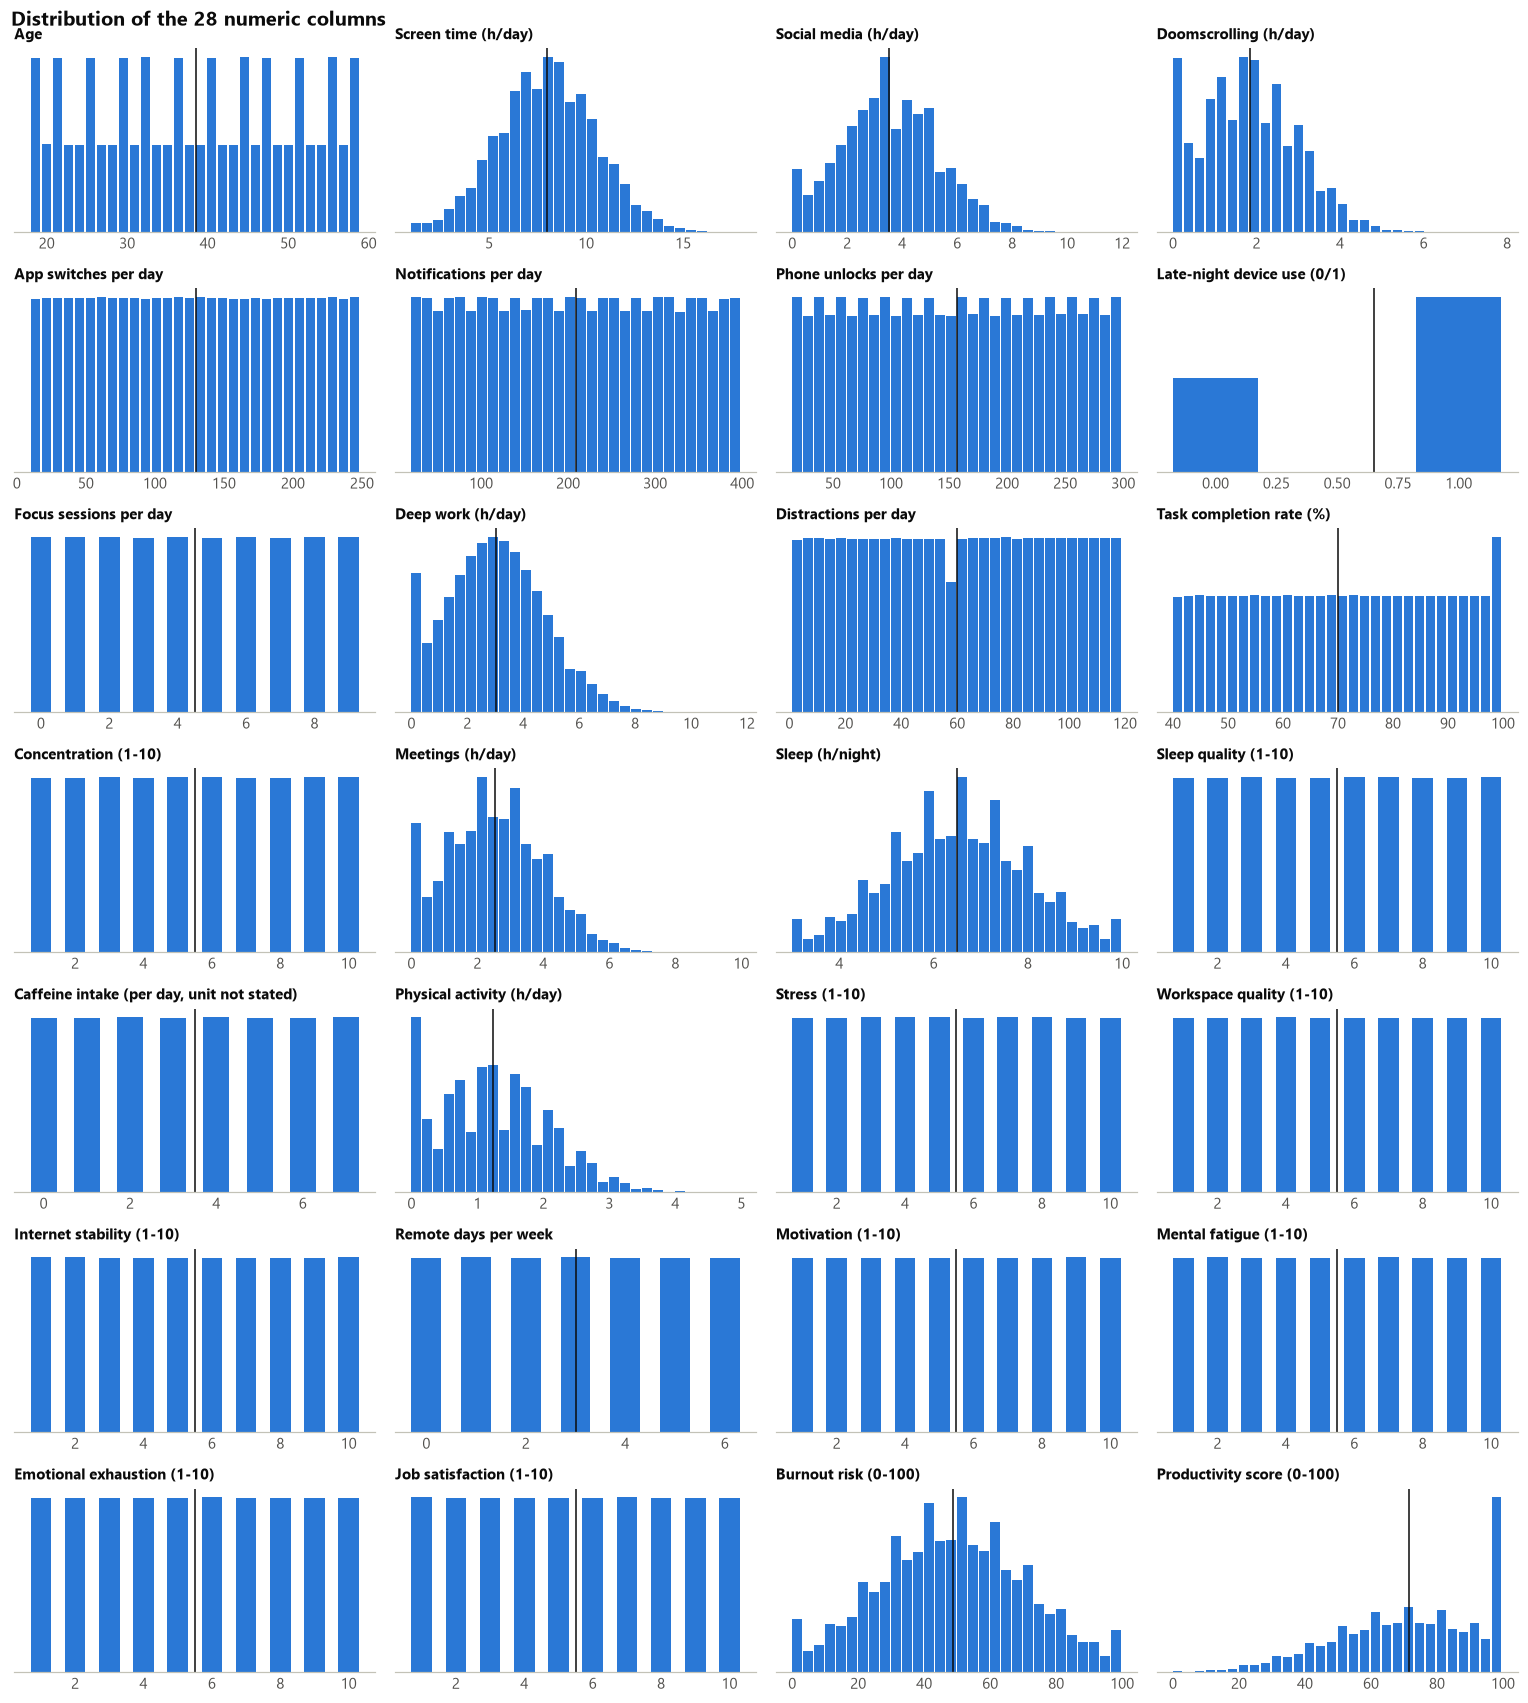

In [7]:
cols = NUMERIC
nc = 4
nr = int(np.ceil(len(cols) / nc))
fig, axes = plt.subplots(nr, nc, figsize=(14, 2.25 * nr))
for ax, c in zip(axes.flat, cols):
    x = df[c].dropna().to_numpy()
    if len(np.unique(x[:200_000])) <= 12:
        vals, cnt = np.unique(x, return_counts=True)
        ax.bar(vals, cnt / len(x), width=0.6 if len(vals) > 2 else 0.35, color=P.BLUE)
    else:
        cnt, edges = np.histogram(x, bins=30)
        ax.bar(edges[:-1], cnt / len(x), width=np.diff(edges) * 0.85, align="edge", color=P.BLUE)
    ax.axvline(x.mean(), color=P.INK, lw=1)
    ax.set_title(lab(c), fontsize=9.5, pad=6)
    ax.set_yticks([])
    ax.spines["left"].set_visible(False)
for ax in list(axes.flat)[len(cols):]:
    ax.axis("off")
fig.suptitle("Distribution of the 28 numeric columns", x=0.01, ha="left", fontsize=13, fontweight="bold")
fig.tight_layout()
plt.show()

### 1.7 Categorical columns

In [8]:
cat_tables = []
for c in CATEGORICAL:
    vc = df[c].value_counts()
    cat_tables.append(pd.DataFrame({"column": lab(c), "value": vc.index.astype(str),
                                    "employees": vc.values, "share %": (vc.values / len(df) * 100).round(2)}))
cat_summary = pd.concat(cat_tables, ignore_index=True)
cat_summary

,column,value,employees,share %
0,Occupation,Freelancer,715500,14.31
1,Occupation,Content Creator,714722,14.29
2,Occupation,Analyst,714478,14.29
3,Occupation,Manager,714213,14.28
4,Occupation,Software Engineer,713889,14.28
5,Occupation,Designer,713772,14.28
6,Occupation,Student,713426,14.27
7,Work mode,Remote,2250774,45.02
8,Work mode,Hybrid,1748165,34.96
9,Work mode,Office,1001061,20.02


### 1.8 Outliers (1.5 × IQR rule)

In [9]:
q1, q3 = df[NUMERIC].quantile(0.25), df[NUMERIC].quantile(0.75)
iqr = q3 - q1
low, high = q1 - 1.5 * iqr, q3 + 1.5 * iqr
n_out = ((df[NUMERIC] < low) | (df[NUMERIC] > high)).sum()
outliers = pd.DataFrame({"label": [short(c) for c in NUMERIC], "lower bound": low, "upper bound": high,
                         "outliers": n_out, "share %": (n_out / len(df) * 100).round(3)})
outliers.sort_values("share %", ascending=False).head(10)

,label,lower bound,upper bound,outliers,share %
daily_screen_time,Screen time,1.20,14.80,34754,0.69
physical_activity,Physical activity,-1.20,3.60,22340,0.45
doomscrolling_duration,Doomscrolling,-1.40,5.00,21632,0.43
social_media_hours,Social media,-1.30,8.30,20490,0.41
deep_work_hours,Deep work,-1.80,7.80,20455,0.41
meeting_hours,Meetings,-1.50,6.50,17087,0.34
productivity_score,Productivity score,5.00,141.00,7707,0.15
age,Age,-3.50,80.50,0,0.00
late_night_device_usage,Late-night device use,-1.50,2.50,0,0.00
app_switch_frequency,App switches per day,-112.50,371.50,0,0.00


**What this shows (part 1)**
- The data is **clean**: no duplicate IDs or rows. Four columns (social media, deep work, sleep, motivation) are
  each missing exactly 2% of values; later steps fill these with the column median.
- Fewer than 1% of values in any column fall outside the 1.5 × IQR range, and they are plausible (for example
  11 hours of deep work), so they are **kept**.
- Most 1–10 scales and count columns are close to **uniform** (kurtosis about −1.2); the hour-based columns are close
  to **normal**.
- Occupations are evenly split (about 14% each). 45% of employees work remotely, 35% hybrid and 20% in an office.
- The median productivity score is 73/100 and the median burnout risk is 49/100.

## 2. Workplace problems: what goes together with burnout and low productivity?

### 2.1 Correlation of each factor with the two outcomes
The correlation *r* ranges from −1 to 1. A positive *r* means the two measures tend to rise together; a negative
*r* means one tends to fall when the other rises. It does not show cause and effect.

In [10]:
num_imp = df[NUMERIC].fillna(df[NUMERIC].median())
corr = num_imp.corr()
r_out = corr.loc[CLUSTER_FEATURES, OUTCOMES].copy()
r_out.insert(0, "factor", [short(c) for c in r_out.index])
r_out.insert(1, "group", [GROUP_OF[c] for c in r_out.index])
print(f"Correlation between burnout risk and productivity: r = {corr.loc['burnout_risk', 'productivity_score']:.3f}")
r_out.sort_values("burnout_risk", ascending=False)

Correlation between burnout risk and productivity: r = -0.378


,factor,group,burnout_risk,productivity_score
emotional_exhaustion,Emotional exhaustion,Mental state,0.51,-0.18
stress_level,Stress,Sleep & recovery,0.38,-0.14
daily_screen_time,Screen time,Digital load,0.22,-0.08
doomscrolling_duration,Doomscrolling,Digital load,0.20,-0.07
late_night_device_usage,Late-night device use,Digital load,0.16,-0.06
distraction_frequency,Distractions per day,Focus & output,0.15,-0.05
notification_count,Notifications per day,Digital load,0.10,-0.03
focus_sessions,Focus sessions per day,Focus & output,0.00,0.23
motivation_level,Motivation,Mental state,0.00,0.23
workspace_quality,Workspace quality,Work environment,0.00,0.17


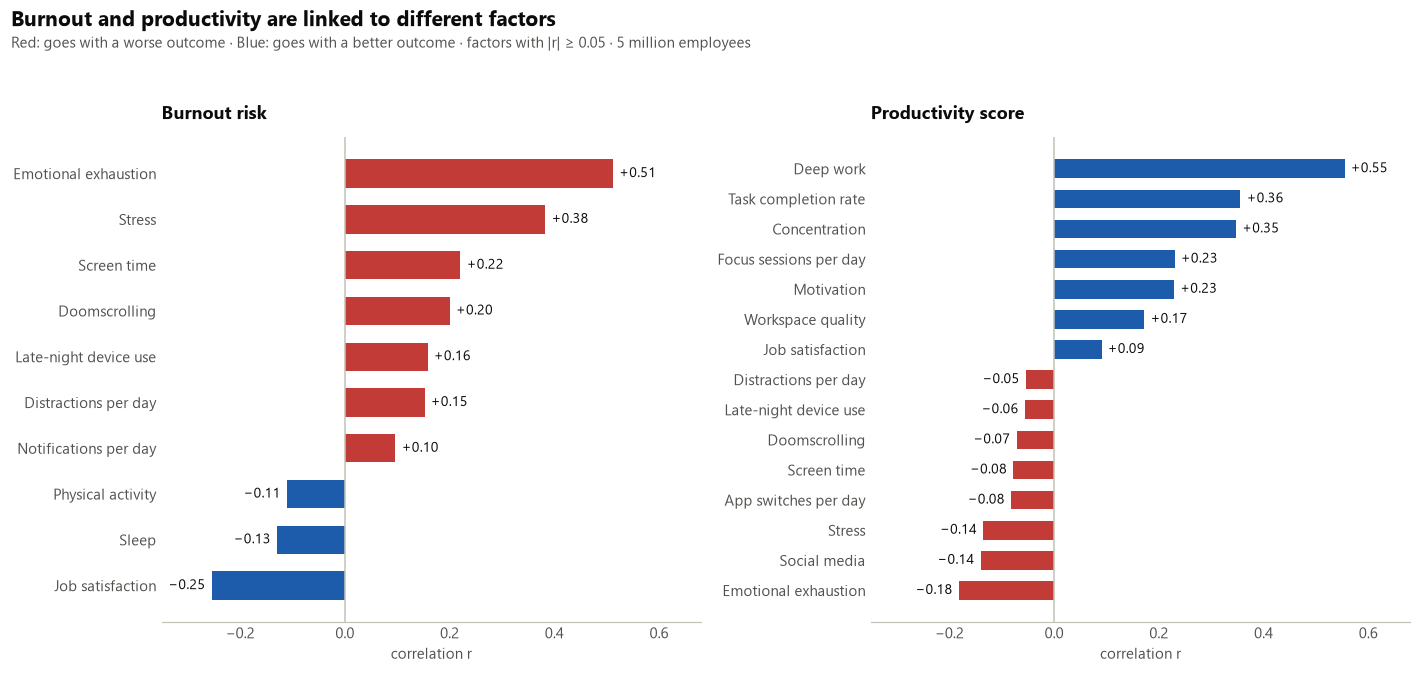

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13, 6.2))
for ax, out, harmful_if_pos, title in [
    (axes[0], "burnout_risk", True, "Burnout risk"),
    (axes[1], "productivity_score", False, "Productivity score"),
]:
    s = r_out[out][r_out[out].abs() >= 0.05].sort_values()
    colors = [P.WORSE if (v > 0) == harmful_if_pos else P.BETTER for v in s]
    y = np.arange(len(s))
    ax.barh(y, s.values, height=0.62, color=colors)
    ax.set_yticks(y, [short(c) for c in s.index])
    ax.axvline(0, color=P.AXIS, lw=1)
    for yi, v in zip(y, s.values):
        ax.text(v + (0.012 if v >= 0 else -0.012), yi, P.num(v, 2, signed=True), va="center",
                ha="left" if v >= 0 else "right", fontsize=9, color=P.INK)
    ax.set_xlim(-0.35, 0.68)
    ax.set_xlabel("correlation r")
    ax.spines["left"].set_visible(False)
    ax.set_title(title)
fig.suptitle("Burnout and productivity are linked to different factors", x=0.01, ha="left",
             fontsize=14, fontweight="bold")
fig.text(0.01, 0.925, "Red: goes with a worse outcome · Blue: goes with a better outcome · factors with |r| ≥ 0.05 · 5 million employees",
         color=P.INK_2, fontsize=10)
fig.tight_layout(rect=(0, 0, 1, 0.92))
P.save(fig, "01_drivers")
plt.show()

### 2.2 Correlation matrix: are the input factors related to each other?

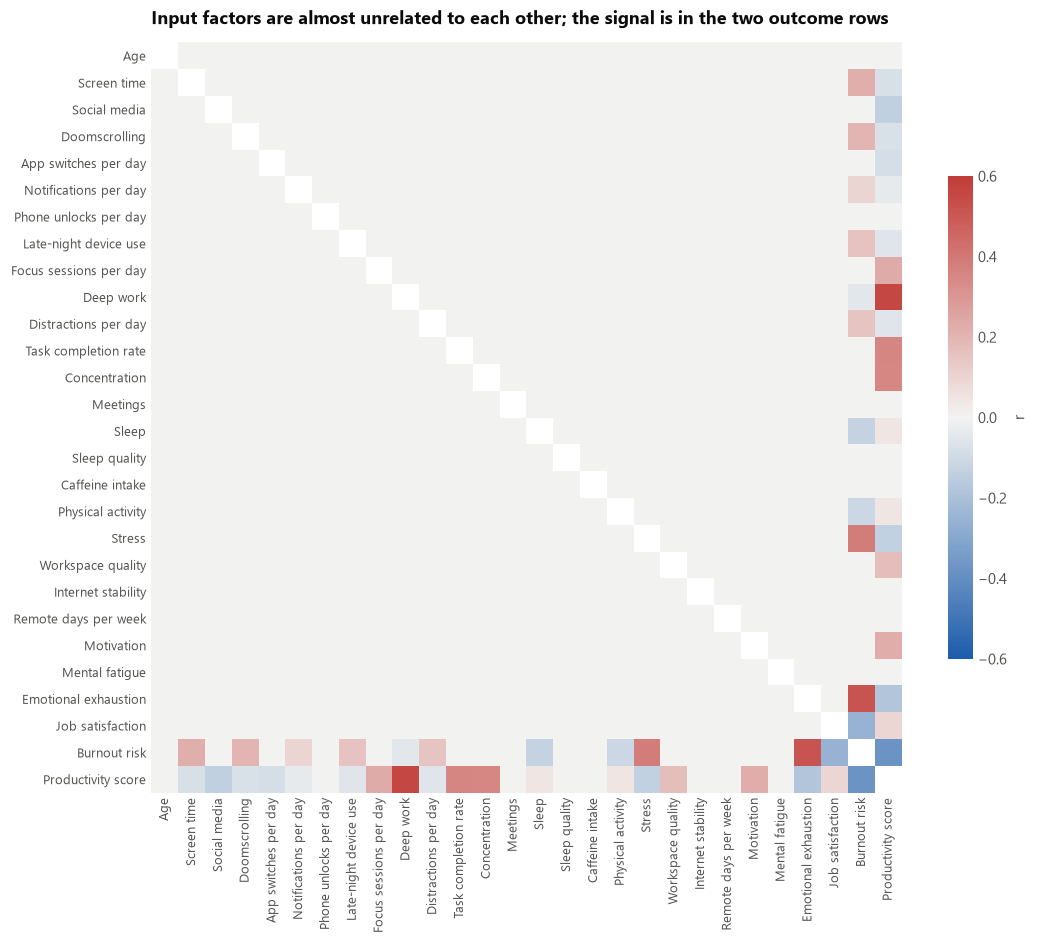

Largest |r| between any two input factors: 0.0012


In [12]:
fig, ax = plt.subplots(figsize=(11, 9.5))
m = corr.to_numpy().copy()
np.fill_diagonal(m, np.nan)
im = ax.imshow(m, cmap=P.DIVERGING, vmin=-0.6, vmax=0.6)
ticks = [short(c) for c in corr.index]
ax.set_xticks(range(len(ticks)), ticks, rotation=90, fontsize=8.5)
ax.set_yticks(range(len(ticks)), ticks, fontsize=8.5)
for sp in ax.spines.values():
    sp.set_visible(False)
cb = fig.colorbar(im, ax=ax, shrink=0.6, label="r")
cb.outline.set_visible(False)
ax.set_title("Input factors are almost unrelated to each other; the signal is in the two outcome rows")
plt.show()
inputs = corr.loc[CLUSTER_FEATURES + ["age"], CLUSTER_FEATURES + ["age"]].to_numpy()
print(f"Largest |r| between any two input factors: {np.nanmax(np.abs(inputs - np.eye(len(inputs)))):.4f}")

### 2.3 Do the outcomes differ by occupation or work mode?

In [13]:
by_dim = []
for dim in ["occupation", "work_mode", "device_usage_type"]:
    g = df.groupby(dim, observed=True).agg(employees=("user_id", "size"), burnout_mean=("burnout_risk", "mean"),
                                           productivity_mean=("productivity_score", "mean"))
    g.insert(0, "dimension", lab(dim))
    by_dim.append(g.rename_axis("value").reset_index())
by_dim = pd.concat(by_dim, ignore_index=True)
display(by_dim)
spread = by_dim.groupby("dimension")[["burnout_mean", "productivity_mean"]].agg(lambda s: s.max() - s.min())
print("Gap between the highest and lowest value (points on a 0-100 scale):")
spread

,value,dimension,employees,burnout_mean,productivity_mean
0,Analyst,Occupation,714478,48.61,71.42
1,Content Creator,Occupation,714722,48.59,71.43
2,Designer,Occupation,713772,48.59,71.46
3,Freelancer,Occupation,715500,48.58,71.46
4,Manager,Occupation,714213,48.58,71.43
5,Software Engineer,Occupation,713889,48.57,71.44
6,Student,Occupation,713426,48.56,71.46
7,Hybrid,Work mode,1748165,48.58,71.46
8,Office,Work mode,1001061,48.58,71.44
9,Remote,Work mode,2250774,48.58,71.44


Gap between the highest and lowest value (points on a 0-100 scale):


,burnout_mean,productivity_mean
dimension,,
Device use type,0.02,0.02
Occupation,0.05,0.04
Work mode,0.01,0.02


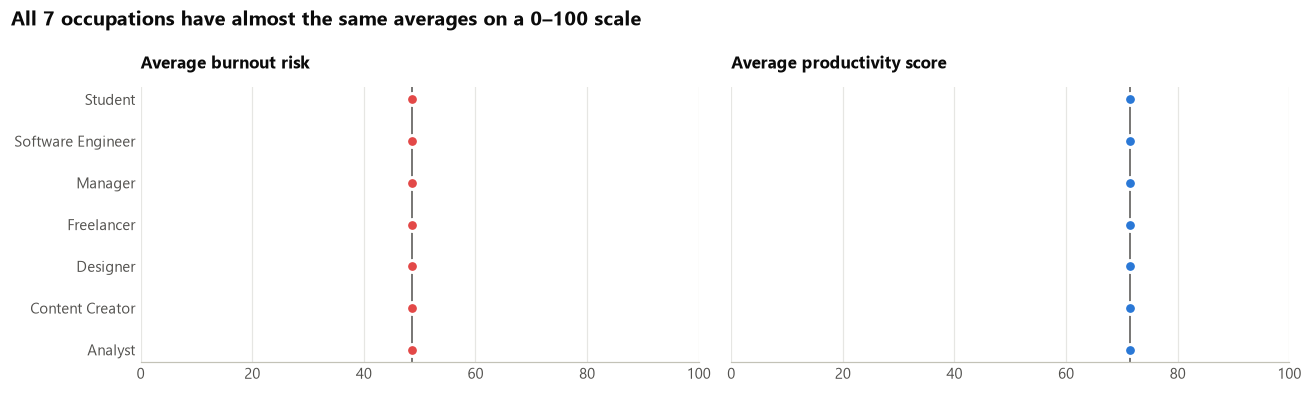

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12, 3.6), sharey=True)
occ = by_dim[by_dim["dimension"] == lab("occupation")].set_index("value")
for ax, col, title, ref, color in [(axes[0], "burnout_mean", "Average burnout risk", df["burnout_risk"].mean(), P.RED),
                                   (axes[1], "productivity_mean", "Average productivity score", df["productivity_score"].mean(), P.BLUE)]:
    y = np.arange(len(occ))
    ax.scatter(occ[col], y, s=60, color=color, zorder=3, edgecolor=P.SURFACE, linewidth=2)
    ax.axvline(ref, color=P.INK_2, lw=1)
    ax.set_xlim(0, 100)
    ax.set_yticks(y, occ.index)
    ax.grid(axis="x")
    ax.set_title(title, fontsize=11)
    ax.spines["left"].set_visible(False)
fig.suptitle("All 7 occupations have almost the same averages on a 0–100 scale", x=0.01, ha="left", fontsize=13, fontweight="bold")
fig.tight_layout()
P.save(fig, "03_job_title_flat")
plt.show()

### 2.4 Warning signs at work
Each warning sign is a simple threshold (for example, sleeping under 6 hours or a stress score of 8 or more).
The thresholds are analysis choices and are defined once in `src/config.py`.

,employees,share %
Late-night device use,3249966,65.00
Sleep under 6 h,1747338,34.95
High emotional exhaustion (8+),1500117,30.00
High mental fatigue (8+),1499460,29.99
High stress (8+),1499416,29.99
Low job satisfaction (3 or less),1498398,29.97
Low motivation (3 or less),1470561,29.41
Deep work under 2 h,1370849,27.42
Screen time over 10 h,1030392,20.61
Burnout risk 70+,894559,17.89


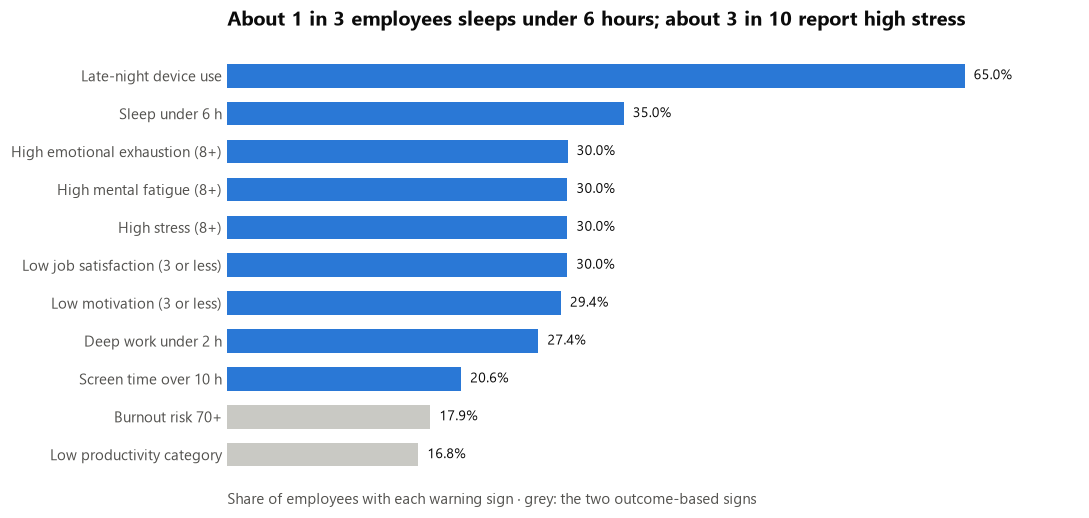

In [15]:
flags = red_flags(df)
flag_tbl = pd.DataFrame({"employees": flags.sum(), "share %": (flags.mean() * 100).round(2)})
flag_tbl = flag_tbl.sort_values("share %", ascending=False)
display(flag_tbl)

fig, ax = plt.subplots(figsize=(10, 4.8))
s = flag_tbl["share %"][::-1]
outcome_flags = ["Burnout risk 70+", "Low productivity category"]
y = np.arange(len(s))
ax.barh(y, s.values, height=0.62, color=[P.DEEMPH if f in outcome_flags else P.BLUE for f in s.index])
ax.set_yticks(y, s.index)
for yi, v in zip(y, s.values):
    ax.text(v + 0.8, yi, P.num(v, 1, suffix="%"), va="center", fontsize=9)
ax.set_xlim(0, 75)
ax.set_xticks([])
ax.spines[["left", "bottom"]].set_visible(False)
ax.set_title("About 1 in 3 employees sleeps under 6 hours; about 3 in 10 report high stress", fontsize=13)
ax.text(0, -1.3, "Share of employees with each warning sign · grey: the two outcome-based signs", color=P.INK_2, fontsize=9.5)
fig.tight_layout()
P.save(fig, "02_red_flags")
plt.show()

### 2.5 Do problems come together?

Average 3.32 of 11 warning signs per employee; 41.7% have 4 or more; 2.1% have none.


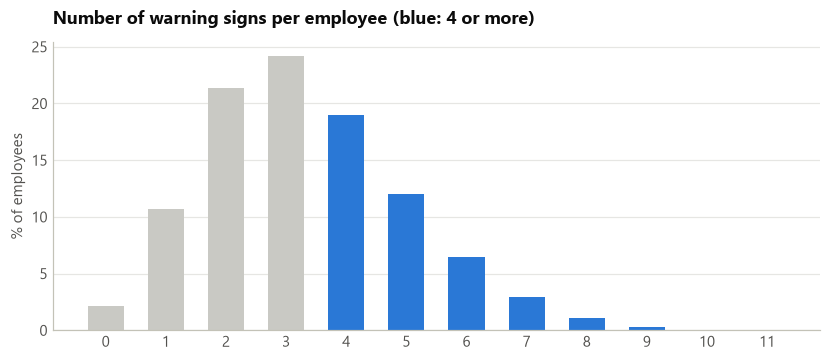

In [16]:
n_flags = flags.sum(axis=1)
dist = n_flags.value_counts(normalize=True).sort_index() * 100
print(f"Average {n_flags.mean():.2f} of {flags.shape[1]} warning signs per employee; "
      f"{(n_flags >= 4).mean():.1%} have 4 or more; {(n_flags == 0).mean():.1%} have none.")
fig, ax = plt.subplots(figsize=(9, 3.4))
ax.bar(dist.index, dist.values, width=0.6, color=[P.BLUE if k >= 4 else P.DEEMPH for k in dist.index])
ax.set_xticks(dist.index)
ax.set_ylabel("% of employees")
ax.grid(axis="y")
ax.set_axisbelow(True)
ax.set_title("Number of warning signs per employee (blue: 4 or more)")
plt.show()

### 2.6 Self-reported mental state

In [17]:
ms = df.groupby("mental_state", observed=True).agg(share=("user_id", "size"), burnout_mean=("burnout_risk", "mean"),
                                                    productivity_mean=("productivity_score", "mean"),
                                                    emotional_exhaustion_mean=("emotional_exhaustion", "mean"))
ms["share"] = ms["share"] / len(df) * 100
ms.sort_values("burnout_mean", ascending=False)

,share,burnout_mean,productivity_mean,emotional_exhaustion_mean
mental_state,,,,
Burnout,19.99,62.79,66.52,5.50
Balanced,25.02,48.10,71.63,5.50
Distracted,30.00,48.08,71.63,5.50
Focused,24.99,38.31,74.97,5.50


**What this shows (part 2)**
- **Two outcomes, two sets of factors.** Higher burnout risk goes with *emotional exhaustion* (r = 0.51), *stress*
  (0.38) and digital habits (*screen time* 0.22, *doomscrolling* 0.20, late-night device use 0.16). Lower burnout
  risk goes with *job satisfaction* (−0.25), *sleep* (−0.13) and *physical activity* (−0.11). Higher productivity
  goes with *deep work* (0.56), *task completion* (0.36), *concentration* (0.35), *motivation* and *focus sessions*
  (0.23 each) and *workspace quality* (0.17). A programme aimed at burnout is therefore unlikely to raise
  productivity on its own, and the reverse.
- **Common problems:** 65% use devices late at night, 35% sleep under 6 hours, and about 30% report high stress, high
  emotional exhaustion, high mental fatigue or low job satisfaction.
- **Problems add up:** employees have 3.3 warning signs on average, and 42% have 4 or more.
- **Not a job-title issue:** average burnout differs by only 0.05 points (out of 100) across the 7 occupations and by
  0.01 points across the 3 work modes. The differences are in individual behaviour, so the next step groups people by
  behaviour rather than by department. Self-reported mental state ("Burnout" vs "Focused") does shift the outcome
  scores even though the behaviours are the same across its categories.
- The input factors are almost unrelated to each other (|r| < 0.01). This is a sign of synthetic data.

## 3. Employee segmentation

**In plain terms:** the 25 behaviour measures are combined into **5 problem scores**. The K-Means algorithm then
puts people with a similar mix of problem scores in the same group. Each group is named after the scores where it
differs most from the average.

### 3.1 Combine 25 measures into 5 problem scores

In [18]:
for name, members in INDEX_DEF.items():
    print(f"{INDEX_LABELS[name]:18s}: " + ", ".join(f"{'+' if s > 0 else '−'}{short(c)}" for c, s in members.items()))
X_df = build_indices(num_imp)
r_idx = pd.concat([X_df, df[OUTCOMES]], axis=1).corr().loc[INDEX_COLS, OUTCOMES]
print("\nCorrelation between the scores (close to 0 = no overlap):")
display(X_df.corr().rename(index=INDEX_LABELS, columns=INDEX_LABELS).round(3))
print("Correlation of each score with the outcomes:")
r_idx.rename(index=INDEX_LABELS).round(3)

Digital overload  : +Screen time, +Social media, +Doomscrolling, +App switches per day, +Notifications per day, +Phone unlocks per day, +Late-night device use
Poor recovery     : −Sleep, −Sleep quality, −Physical activity, +Caffeine intake, +Stress
Focus capacity    : +Deep work, +Focus sessions per day, +Concentration, +Task completion rate, −Distractions per day
Mental strain     : +Mental fatigue, +Emotional exhaustion, −Motivation, −Job satisfaction
Work environment  : +Workspace quality, +Internet stability



Correlation between the scores (close to 0 = no overlap):


,Digital overload,Poor recovery,Focus capacity,Mental strain,Work environment
Digital overload,1.00,0.00,0.00,0.00,-0.00
Poor recovery,0.00,1.00,0.00,0.00,-0.00
Focus capacity,0.00,0.00,1.00,-0.00,-0.00
Mental strain,0.00,0.00,-0.00,1.00,-0.00
Work environment,-0.00,-0.00,-0.00,-0.00,1.00


Correlation of each score with the outcomes:


,burnout_risk,productivity_score
Digital overload,0.26,-0.17
Poor recovery,0.28,-0.10
Focus capacity,-0.09,0.69
Mental strain,0.38,-0.25
Work environment,-0.00,0.12


### 3.2 Does the data have natural clusters? (PCA)

In [19]:
rng = np.random.default_rng(RANDOM_STATE)
pca_idx = rng.choice(len(X_df), size=min(50_000, len(X_df)), replace=False)
pca = PCA(random_state=RANDOM_STATE).fit(X_df.to_numpy()[pca_idx])
pca_tbl = pd.DataFrame({"variance %": pca.explained_variance_ratio_ * 100,
                        "cumulative %": pca.explained_variance_ratio_.cumsum() * 100},
                       index=[f"PC{i + 1}" for i in range(len(INDEX_COLS))])
pca_tbl

,variance %,cumulative %
PC1,20.21,20.21
PC2,20.11,40.32
PC3,20.00,60.33
PC4,19.96,80.28
PC5,19.72,100.00


Each component explains about 20% of the variance, so the data forms one even cloud with **no separate natural
clusters**. The silhouette score will be low whatever grouping is used, and if all five scores have equal weight,
K-Means gives different answers on different runs. The next two steps deal with this.

### 3.3 Weight each score by how strongly it relates to the outcomes
A score gets more weight when it is more strongly linked to burnout **and** productivity (both outcomes count
equally).

In [20]:
r_abs = r_idx.abs()
weights = (r_abs / r_abs.max()).sum(axis=1)
X_eq = X_df.to_numpy(dtype=np.float64)
X = X_eq * weights.to_numpy()
weights.rename(index=INDEX_LABELS).sort_values(ascending=False).to_frame("weight")

,weight
Mental strain,1.36
Focus capacity,1.23
Digital overload,0.92
Poor recovery,0.87
Work environment,0.18


### 3.4 Choose the number of groups *k*
For each k from 2 to 8, K-Means is run 5 times (5 random seeds) on a sample of 300,000 employees, measuring:
- **stability**: whether different runs give the same grouping (adjusted Rand index, ARI; 1 = identical);
- **eta²**: how much of the variation in burnout / productivity is explained by knowing a person's group;
- silhouette, Calinski-Harabasz and Davies-Bouldin: standard geometric scores.

Rule: among k = 3–6 (the number of programmes HR can realistically run in parallel), keep values of k with
stability ≥ 0.8 and a smallest group ≥ 10%, then choose the k that separates the outcomes best.
*(This cell takes about 3 minutes.)*

In [21]:
SEL_SAMPLE, METRIC_SAMPLE, N_SEEDS = 300_000, 20_000, 5
sel_idx = rng.choice(len(X), size=min(SEL_SAMPLE, len(X)), replace=False)
met_idx = sel_idx[:METRIC_SAMPLE]
Xs, Xs_eq = X[sel_idx], X_eq[sel_idx]
out_s = df[OUTCOMES].iloc[sel_idx].reset_index(drop=True)
rows, sample_labels = [], {}
t0 = time.perf_counter()
for k in range(2, 9):
    labs = [KMeans(k, n_init=10, random_state=s).fit(Xs).labels_ for s in range(N_SEEDS)]
    labs_eq = [KMeans(k, n_init=10, random_state=s).fit(Xs_eq).labels_ for s in range(N_SEEDS)]
    stab, stab_min = mean_pairwise_ari(labs)
    lab0 = sample_labels[k] = labs[0]
    lab_m = lab0[:len(met_idx)]
    rows.append({"k": k, "stability_equal": mean_pairwise_ari(labs_eq)[0], "stability": stab,
                 "stability_min": stab_min, "silhouette": silhouette_score(X[met_idx], lab_m),
                 "calinski_harabasz": calinski_harabasz_score(X[met_idx], lab_m),
                 "davies_bouldin": davies_bouldin_score(X[met_idx], lab_m),
                 "eta2_burnout": eta_squared(out_s["burnout_risk"], lab0),
                 "eta2_productivity": eta_squared(out_s["productivity_score"], lab0),
                 "min_share_%": np.bincount(lab0).min() / len(lab0) * 100})
    print(f"k={k} done ({time.perf_counter() - t0:,.0f} s)")
k_tbl = pd.DataFrame(rows).set_index("k")
cand = k_tbl.loc[3:6]
passing = cand[(cand["stability"] >= 0.8) & (cand["min_share_%"] >= 10)]
K = int((passing["eta2_burnout"] + passing["eta2_productivity"]).idxmax()) if len(passing) else int(cand["stability"].idxmax())
print(f"\n=> Chosen k = {K}")
k_tbl.round(3)

k=2 done (10 s)


k=3 done (23 s)


k=4 done (43 s)


k=5 done (71 s)


k=6 done (99 s)


k=7 done (129 s)


k=8 done (166 s)

=> Chosen k = 6


,stability_equal,stability,stability_min,silhouette,calinski_harabasz,davies_bouldin,eta2_burnout,eta2_productivity,min_share_%
k,,,,,,,,,
2,0.69,0.87,0.75,0.22,"6,385.66",1.66,0.10,0.04,46.56
3,0.40,0.54,0.27,0.20,"5,860.60",1.47,0.09,0.27,31.78
4,0.47,0.89,0.73,0.17,"5,230.03",1.58,0.10,0.37,23.35
5,0.41,0.89,0.79,0.17,"4,643.36",1.47,0.12,0.38,18.28
6,0.35,0.92,0.86,0.17,"4,312.36",1.39,0.13,0.37,16.47
7,0.26,0.85,0.69,0.17,"4,093.77",1.36,0.14,0.41,13.15
8,0.25,0.61,0.37,0.17,"3,928.87",1.29,0.16,0.40,11.87


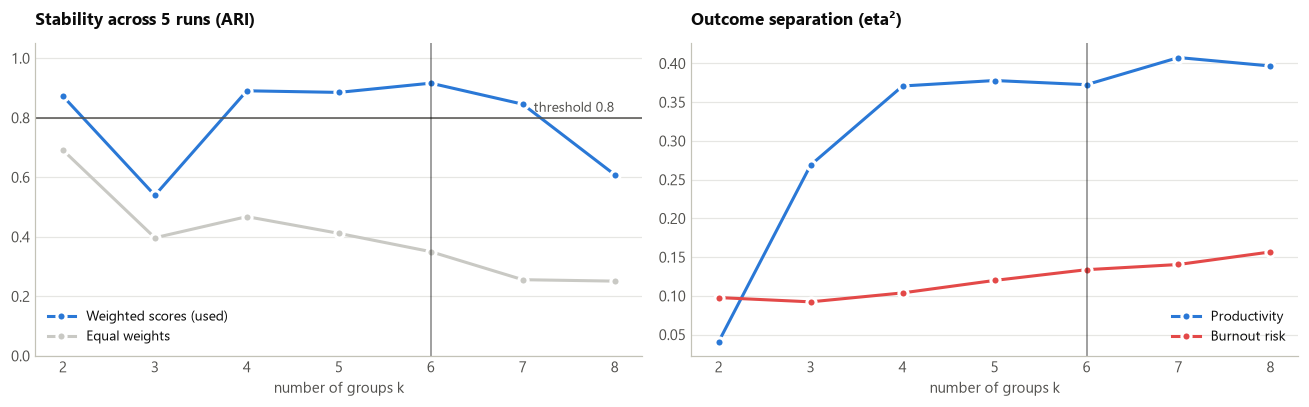

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(12, 3.8))
ks = k_tbl.index
ax = axes[0]
ax.plot(ks, k_tbl["stability"], color=P.BLUE, lw=2, marker="o", ms=6, mec=P.SURFACE, mew=2, label="Weighted scores (used)")
ax.plot(ks, k_tbl["stability_equal"], color=P.DEEMPH, lw=2, marker="o", ms=6, mec=P.SURFACE, mew=2, label="Equal weights")
ax.axhline(0.8, color=P.INK_2, lw=1)
ax.text(8, 0.82, "threshold 0.8", ha="right", fontsize=9, color=P.INK_2)
ax.set_ylim(0, 1.05)
ax.set_title("Stability across 5 runs (ARI)", fontsize=11)
ax.legend(loc="lower left")
ax = axes[1]
ax.plot(ks, k_tbl["eta2_productivity"], color=P.BLUE, lw=2, marker="o", ms=6, mec=P.SURFACE, mew=2, label="Productivity")
ax.plot(ks, k_tbl["eta2_burnout"], color=P.RED, lw=2, marker="o", ms=6, mec=P.SURFACE, mew=2, label="Burnout risk")
ax.set_title("Outcome separation (eta²)", fontsize=11)
ax.legend(loc="lower right")
for ax in axes:
    ax.axvline(K, color=P.INK, lw=1, alpha=0.5)
    ax.set_xlabel("number of groups k")
    ax.grid(axis="y")
    ax.set_axisbelow(True)
fig.tight_layout()
plt.show()

### 3.5 K-Means on all 5 million employees, checked against two other methods
A useful grouping should be **reproducible**: the sample and the full data should agree, and a different algorithm
should find similar groups.

In [23]:
t0 = time.perf_counter()
km = KMeans(K, n_init=10, random_state=RANDOM_STATE).fit(X)
labels = km.labels_
print(f"K-Means k={K} on {len(X):,} employees: {time.perf_counter() - t0:,.0f} s")

gmm_idx = rng.choice(len(X), size=min(200_000, len(X)), replace=False)
gmm = GaussianMixture(K, covariance_type="full", random_state=RANDOM_STATE, n_init=3).fit(X[gmm_idx])
ward_idx = rng.choice(len(X), size=min(10_000, len(X)), replace=False)
ward = AgglomerativeClustering(K, linkage="ward").fit(X[ward_idx])
validation = pd.Series({
    "ARI: 300k sample vs full data": adjusted_rand_score(sample_labels[K], labels[sel_idx]),
    "ARI: K-Means vs Gaussian Mixture (200k)": adjusted_rand_score(labels[gmm_idx], gmm.predict(X[gmm_idx])),
    "ARI: K-Means vs Ward hierarchical (10k)": adjusted_rand_score(labels[ward_idx], ward.labels_),
    "Silhouette (20k)": silhouette_score(X[met_idx], labels[met_idx]),
}, name="value")
validation.round(3).to_frame()

K-Means k=6 on 5,000,000 employees: 41 s


,value
ARI: 300k sample vs full data,0.99
ARI: K-Means vs Gaussian Mixture (200k),0.81
ARI: K-Means vs Ward hierarchical (10k),0.26
Silhouette (20k),0.17


The sample and the full data give almost the same grouping, and Gaussian Mixture (a different algorithm) agrees
well with K-Means. Ward agrees less: the **core** of each group is stable, but the **borders** between groups are a
choice. This is expected when the data has no natural clusters (section 3.2).

### 3.6 Group profiles and names
- Each group is named after up to two scores that are at least 0.3 standard deviations (SD) away from the average.
- **Risk score** = how far the group's burnout is above average + how far its productivity is below average (in SD).
  High productivity does **not** cancel out high burnout, because a strong performer who is burning out is still a
  retention risk.

In [24]:
df["segment_id"] = labels.astype("int8")
X_df["segment_id"] = labels
problem_z = X_df.groupby("segment_id")[INDEX_COLS].mean() * pd.Series(PROBLEM_SIGN)
outcome_mean = df.groupby("segment_id")[OUTCOMES].mean()
pop_b, pop_p = df["burnout_risk"].mean(), df["productivity_score"].mean()
z_burn = (outcome_mean["burnout_risk"] - pop_b) / df["burnout_risk"].std()
z_prod_gap = (pop_p - outcome_mean["productivity_score"]) / df["productivity_score"].std()
risk_score = z_burn.clip(lower=0) + z_prod_gap.clip(lower=0)
order = sorted(risk_score.index, key=lambda s: (risk_score[s], z_burn[s] + z_prod_gap[s]), reverse=True)
code = {s: f"N{i}" for i, s in enumerate(order, start=1)}
names = {s: name_segment(problem_z.loc[s]) for s in order}
level = {s: risk_level(risk_score[s]) for s in order}
sizes = df["segment_id"].value_counts()
flag_rate_seg = flags.groupby(df["segment_id"]).mean()

summary = pd.DataFrame({
    "name": [names[s] for s in order],
    "risk level": [level[s][0] for s in order],
    "employees": [int(sizes[s]) for s in order],
    "share %": [sizes[s] / len(df) * 100 for s in order],
    "burnout mean": [outcome_mean.loc[s, "burnout_risk"] for s in order],
    "productivity mean": [outcome_mean.loc[s, "productivity_score"] for s in order],
    "% burnout 70+": [flag_rate_seg.loc[s, "Burnout risk 70+"] * 100 for s in order],
    "% low productivity": [flag_rate_seg.loc[s, "Low productivity category"] * 100 for s in order],
    "warning signs per person": [n_flags[df["segment_id"] == s].mean() for s in order],
    "risk score": [risk_score[s] for s in order],
}, index=pd.Index([code[s] for s in order], name="code"))
print(f"All employees: burnout mean {pop_b:.1f} | productivity mean {pop_p:.1f} | {n_flags.mean():.2f} warning signs per person")
summary

All employees: burnout mean 48.6 | productivity mean 71.4 | 3.32 warning signs per person


,name,risk level,employees,share %,burnout mean,productivity mean,% burnout 70+,% low productivity,warning signs per person,risk score
code,,,,,,,,,,
N1,Low focus + mental strain,Very high,835607,16.71,58.89,49.51,31.01,49.59,4.69,1.49
N2,Heavy device use,High,829775,16.60,54.56,67.85,24.12,16.11,3.59,0.44
N3,Low focus + low mental strain,High,836373,16.73,41.19,63.84,9.00,23.27,2.69,0.35
N4,Mental strain + strong focus,High,839807,16.80,55.76,80.43,26.07,4.74,3.97,0.33
N5,Light device use,Low,824113,16.48,42.60,76.19,10.04,6.76,2.75,0.00
N6,Strong focus + low mental strain,Low,834325,16.69,38.41,90.88,7.00,0.39,2.23,0.00


### 3.7 The six groups on a burnout × productivity map

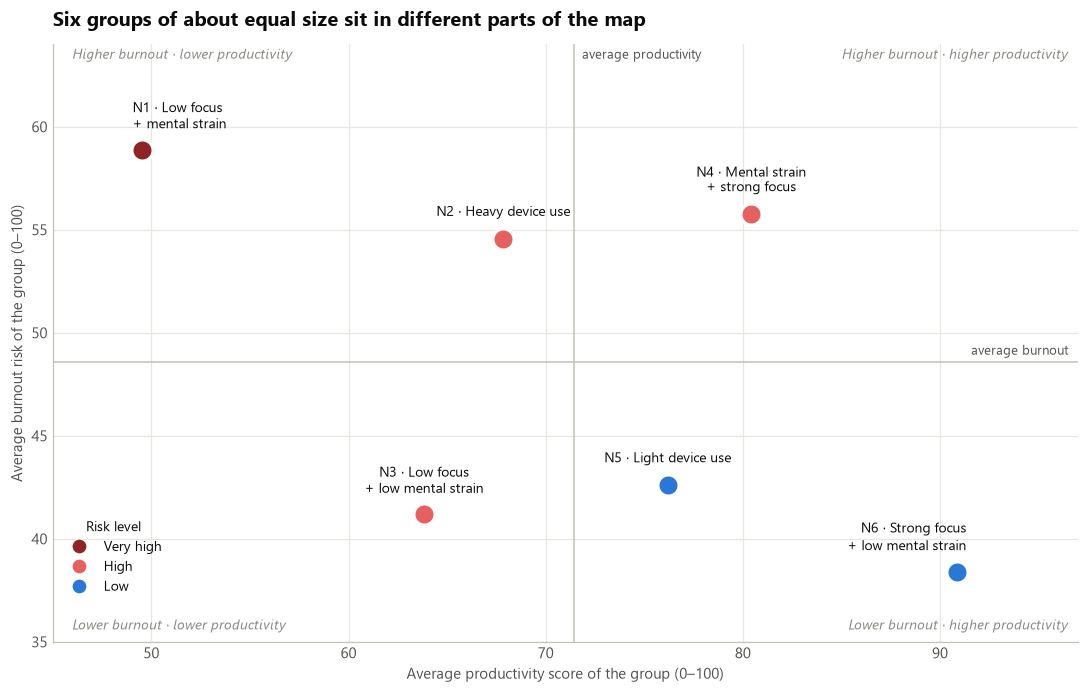

In [25]:
fig, ax = plt.subplots(figsize=(10, 6.4))
ax.axvline(pop_p, color=P.AXIS, lw=1)
ax.axhline(pop_b, color=P.AXIS, lw=1)
ax.text(pop_p + 0.4, 63.3, "average productivity", fontsize=8.5, color=P.INK_2)
ax.text(96.5, pop_b + 0.35, "average burnout", fontsize=8.5, color=P.INK_2, ha="right")
for txt, x, y, ha in [("Higher burnout · lower productivity", 46, 63.3, "left"), ("Higher burnout · higher productivity", 96.5, 63.3, "right"),
                      ("Lower burnout · lower productivity", 46, 35.6, "left"), ("Lower burnout · higher productivity", 96.5, 35.6, "right")]:
    ax.text(x, y, txt, fontsize=9, color=P.MUTED, ha=ha, style="italic")
for s in order:
    x, y = outcome_mean.loc[s, "productivity_score"], outcome_mean.loc[s, "burnout_risk"]
    ax.scatter(x, y, s=190, color=P.RISK[level[s][1]], edgecolor=P.SURFACE, linewidth=2, zorder=3)
    ha = "left" if x < 55 else "right" if x > 85 else "center"
    dx = {"left": -6, "right": 6, "center": 0}[ha]
    ax.annotate(f"{code[s]} · {names[s]}".replace(" + ", "\n+ "), (x, y), xytext=(dx, 12), textcoords="offset points",
                ha=ha, va="bottom", fontsize=9, color=P.INK, linespacing=1.25)
handles = [plt.Line2D([], [], marker="o", ls="", ms=10, mfc=P.RISK[st], mec=P.SURFACE, label=lv)
           for _, lv, st in RISK_LEVELS]
ax.legend(handles=handles, title="Risk level", loc="lower left", bbox_to_anchor=(0, 0.06), title_fontsize=9)
ax.set_xlim(45, 97)
ax.set_ylim(35, 64)
ax.set_xlabel("Average productivity score of the group (0–100)")
ax.set_ylabel("Average burnout risk of the group (0–100)")
ax.grid(True)
ax.set_axisbelow(True)
ax.set_title("Six groups of about equal size sit in different parts of the map", fontsize=13)
fig.tight_layout()
P.save(fig, "04_segment_map")
plt.show()

### 3.8 Problem profile of each group
Units are standard deviations from the all-employee average, turned so that **positive (red) = worse than average**.

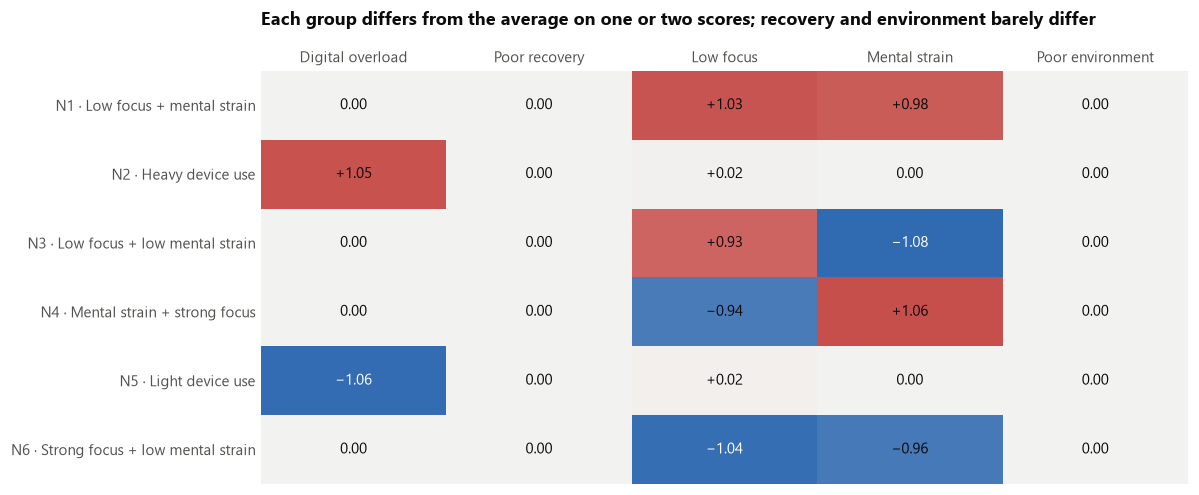

In [26]:
pz = problem_z.loc[order]
fig, ax = plt.subplots(figsize=(11, 4.6))
ax.imshow(pz.to_numpy(), cmap=P.DIVERGING, vmin=-1.2, vmax=1.2, aspect="auto")
ax.set_xticks(range(len(INDEX_COLS)), [PROBLEM_LABELS[c] for c in INDEX_COLS])
ax.set_yticks(range(len(order)), [f"{code[s]} · {names[s]}" for s in order])
ax.xaxis.tick_top()
for i in range(pz.shape[0]):
    for j in range(pz.shape[1]):
        v = pz.iat[i, j]
        ax.text(j, i, P.num(v, 2, signed=True), ha="center", va="center", fontsize=10,
                color=P.text_on(P.cmap_hex(P.DIVERGING, (v + 1.2) / 2.4)))
for sp in ax.spines.values():
    sp.set_visible(False)
ax.set_title("Each group differs from the average on one or two scores; recovery and environment barely differ", fontsize=12, pad=30)
fig.tight_layout()
P.save(fig, "05_segment_profile")
plt.show()

### 3.9 Warning signs by group, and problems shared by everyone

In [27]:
flag_order = flag_tbl.index.tolist()
fr = flag_rate_seg.loc[order, flag_order].T * 100
fr.columns = [code[s] for s in order]
fr["All"] = flags.mean()[flag_order] * 100
flag_spread = (fr.drop(columns="All").max(axis=1) - fr.drop(columns="All").min(axis=1))
fr["gap (pp)"] = flag_spread
company_wide = flag_spread[flag_spread < CROSS_CUTTING_PP].index.tolist()
display(fr.round(1))
print("Shared by all groups (rate differs by < 5 percentage points between groups):", ", ".join(company_wide))

,N1,N2,N3,N4,N5,N6,All,gap (pp)
Late-night device use,65.70,82.80,65.60,65.60,44.50,65.70,65.00,38.30
Sleep under 6 h,35.00,35.00,35.00,35.00,34.90,34.90,34.90,0.10
High emotional exhaustion (8+),48.70,28.10,11.30,50.60,28.10,13.00,30.00,39.20
High mental fatigue (8+),48.60,28.20,11.30,50.50,28.10,13.00,30.00,39.30
High stress (8+),30.00,30.00,29.90,30.10,29.90,30.00,30.00,0.20
Low job satisfaction (3 or less),48.70,28.10,11.30,50.50,28.10,13.00,30.00,39.20
Low motivation (3 or less),47.90,27.40,11.10,49.60,27.60,12.70,29.40,38.50
Deep work under 2 h,43.50,26.30,41.60,14.00,26.40,12.80,27.40,30.70
Screen time over 10 h,20.20,32.80,20.20,20.20,10.20,20.10,20.60,22.50
Burnout risk 70+,31.00,24.10,9.00,26.10,10.00,7.00,17.90,24.00


Shared by all groups (rate differs by < 5 percentage points between groups): Sleep under 6 h, High stress (8+)


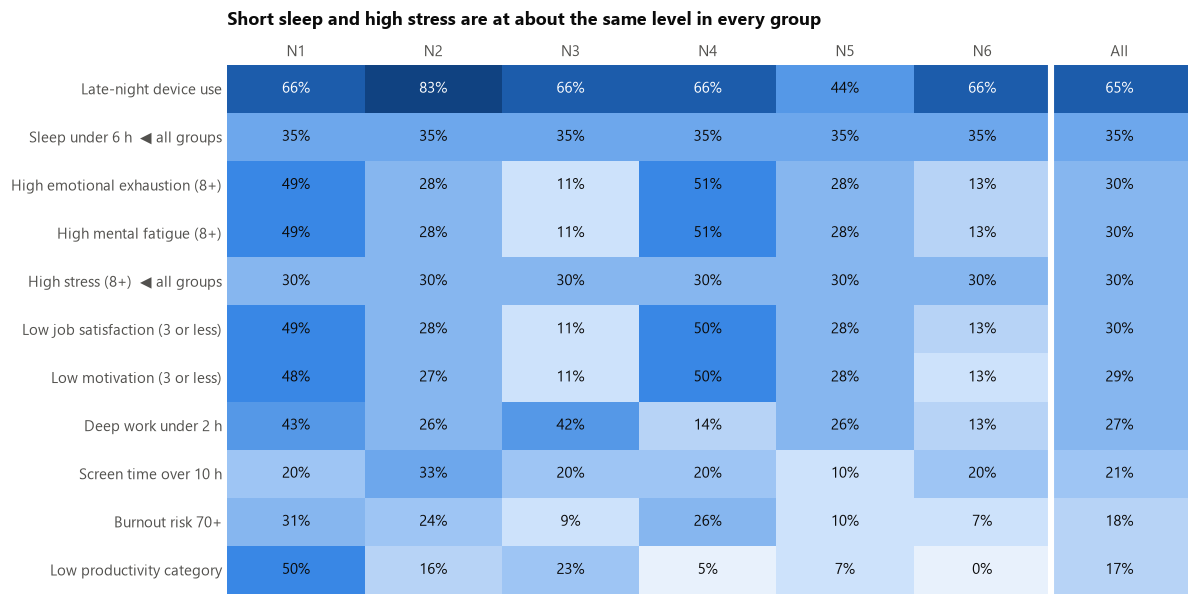

In [28]:
data = fr.drop(columns="gap (pp)")
fig, ax = plt.subplots(figsize=(11, 5.6))
vmax = data.to_numpy().max()
ax.imshow(data.to_numpy(), cmap=P.SEQUENTIAL, vmin=0, vmax=vmax, aspect="auto")
ax.set_xticks(range(data.shape[1]), data.columns)
ax.set_yticks(range(data.shape[0]), [f + ("  ◀ all groups" if f in company_wide else "") for f in data.index])
ax.xaxis.tick_top()
for i in range(data.shape[0]):
    for j in range(data.shape[1]):
        v = data.iat[i, j]
        ax.text(j, i, P.num(v, 0, suffix="%"), ha="center", va="center", fontsize=9.5,
                color=P.text_on(P.cmap_hex(P.SEQUENTIAL, v / vmax)))
ax.axvline(data.shape[1] - 1.5, color=P.SURFACE, lw=4)
for sp in ax.spines.values():
    sp.set_visible(False)
ax.set_title("Short sleep and high stress are at about the same level in every group", fontsize=12, pad=26)
fig.tight_layout()
P.save(fig, "06_flags_by_segment")
plt.show()

### 3.10 Do the groups match occupation or work mode?

In [29]:
comp = []
for c in ["occupation", "work_mode", "device_usage_type", "mental_state"]:
    ct = pd.crosstab(df["segment_id"], df[c], normalize="index").mul(100).loc[order]
    ct.index = [code[s] for s in order]
    comp.append(ct.T.assign(column=lab(c)).set_index("column", append=True).swaplevel())
pd.concat(comp).round(1)

N1    N2    N3    N4    N5    N6
column                                                                              
Occupation                 Analyst               14.30 14.40 14.20 14.30 14.30 14.30
                           Content Creator       14.30 14.30 14.30 14.30 14.30 14.30
                           Designer              14.30 14.20 14.30 14.30 14.30 14.20
                           Freelancer            14.40 14.30 14.30 14.30 14.30 14.30
                           Manager               14.30 14.30 14.40 14.30 14.20 14.30
                           Software Engineer     14.30 14.30 14.30 14.30 14.30 14.30
                           Student               14.20 14.30 14.30 14.20 14.30 14.30
Work mode                  Hybrid                35.10 34.90 34.90 35.00 35.00 35.00
                           Office                20.00 20.10 20.00 20.10 20.00 20.00
                           Remote                45.00 45.10 45.10 44.90 45.00 45.00
Device use type            Balanced              35.00 35.00 34.90 35.00 35.00 35.00
                           Entertainment-Centric 30.00 30.10 30.10 30.00 30.00 30.00
                           Work-Centric          35.00 34.90 35.00 35.10 35.00 35.00
Self-reported mental state Balanced              25.00 25.10 25.00 25.00 25.00 24.90
                           Burnout               20.00 19.90 20.00 20.00 20.00 20.10
                           Distracted            30.00 30.00 30.00 30.00 30.00 30.00
                           Focused               25.00 25.00 25.00 25.00 25.00 25.00

### 3.11 Does the grouping explain the outcomes?

In [30]:
eta = {t: eta_squared(df[t], labels) for t in OUTCOMES}
pd.DataFrame({"eta²": eta, "gap between highest and lowest group (points)":
              {t: outcome_mean[t].max() - outcome_mean[t].min() for t in OUTCOMES}}).rename(index=lab)

,eta²,gap between highest and lowest group (points)
Burnout risk (0-100),0.13,20.48
Productivity score (0-100),0.37,41.36


**What this shows (part 3)**
- Six groups, each about 16–17% of employees. Knowing a person's group explains **37% of the variation in
  productivity** and 13% of the variation in burnout risk. Average productivity differs by 41 points between the
  highest and lowest group.
- **N1 – Low focus + mental strain (16.7%)** has the highest risk: burnout 58.9, productivity 49.5. About half are
  in the low productivity category and 31% have a burnout risk of 70 or more.
- **N4 – Mental strain + strong focus** is easy to miss: productivity is high (80.4), but burnout is 55.8 and about
  half report high emotional exhaustion.
- The groups do not follow occupation, work mode or self-reported mental state (the mix is about the same in every
  group), so targeting has to use behaviour data rather than the org chart.
- **Short sleep (35%) and high stress (30%)** are at almost the same level in every group. Grouping does not help to
  target them, so they call for company-wide measures.

## 4. Comparing groups that share the same risk level

A common approach is to ask "who is high risk?" and give everyone in that bucket the same programme. This part
checks whether groups with the **same risk level** are actually alike: in outcomes, in problem profile, in behaviour,
and in which factors go with burnout and productivity **inside** each group.

### 4.1 Which groups are in each risk level?

In [31]:
levels = pd.DataFrame({"risk level": [level[s][0] for s in order], "code": [code[s] for s in order],
                       "name": [names[s] for s in order], "share %": [sizes[s] / len(df) * 100 for s in order]})
display(levels.groupby("risk level", sort=False).agg(groups=("code", ", ".join), share=("share %", "sum")))
FOCUS_LEVEL = "High"
focus = [s for s in order if level[s][0] == FOCUS_LEVEL]
print(f"Detailed look at the '{FOCUS_LEVEL}' level: {', '.join(code[s] for s in focus)}")

,groups,share
risk level,,
Very high,N1,16.71
High,"N2, N3, N4",50.12
Low,"N5, N6",33.17


Detailed look at the 'High' level: N2, N3, N4


### 4.2 Same "High" risk level, three different main problems

In [32]:
raw_mean = num_imp[CLUSTER_FEATURES + OUTCOMES].groupby(labels).mean()
pop_mean, pop_std = num_imp[CLUSTER_FEATURES].mean(), num_imp[CLUSTER_FEATURES].std()
raw_z = (raw_mean[CLUSTER_FEATURES] - pop_mean) / pop_std

for s in focus:
    print(f"{code[s]} · {names[s]}")
cmp = pd.DataFrame({code[s]: {
    "share %": sizes[s] / len(df) * 100,
    "burnout mean": outcome_mean.loc[s, "burnout_risk"],
    "% burnout 70+": flag_rate_seg.loc[s, "Burnout risk 70+"] * 100,
    "productivity mean": outcome_mean.loc[s, "productivity_score"],
    "% low productivity": flag_rate_seg.loc[s, "Low productivity category"] * 100,
    **{f"[score] {PROBLEM_LABELS[c]}": problem_z.loc[s, c] for c in INDEX_COLS},
} for s in focus})
cmp["All"] = {"share %": 100.0, "burnout mean": pop_b, "% burnout 70+": flags["Burnout risk 70+"].mean() * 100,
              "productivity mean": pop_p, "% low productivity": flags["Low productivity category"].mean() * 100,
              **{f"[score] {PROBLEM_LABELS[c]}": 0.0 for c in INDEX_COLS}}
cmp

N2 · Heavy device use
N3 · Low focus + low mental strain
N4 · Mental strain + strong focus


,N2,N3,N4,All
share %,16.60,16.73,16.80,100.00
burnout mean,54.56,41.19,55.76,48.58
% burnout 70+,24.12,9.00,26.07,17.89
productivity mean,67.85,63.84,80.43,71.44
% low productivity,16.11,23.27,4.74,16.83
[score] Digital overload,1.05,0.00,0.00,0.00
[score] Poor recovery,0.00,-0.00,0.00,0.00
[score] Low focus,0.02,0.93,-0.94,0.00
[score] Mental strain,-0.00,-1.08,1.06,0.00
[score] Poor environment,0.00,-0.00,0.00,0.00


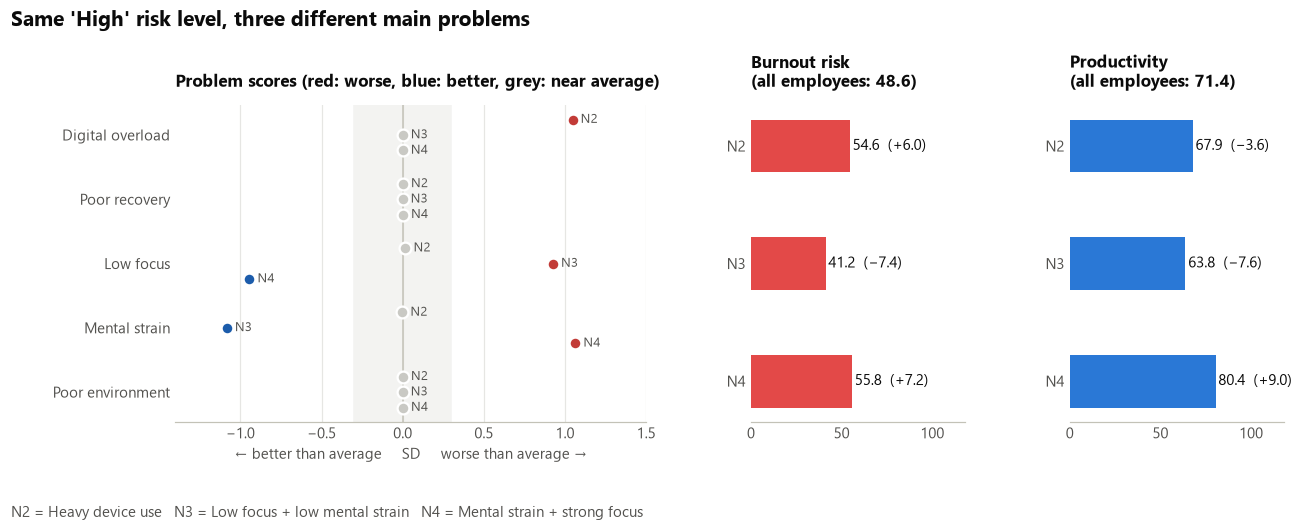

In [33]:
fig = plt.figure(figsize=(13, 4.8))
gs = fig.add_gridspec(1, 3, width_ratios=[2.2, 1, 1], wspace=0.35)
ax = fig.add_subplot(gs[0])
yy = np.arange(len(INDEX_COLS))[::-1]
ax.axvline(0, color=P.AXIS, lw=1)
ax.axvspan(-NAME_THRESHOLD, NAME_THRESHOLD, color=P.DIV_MID, zorder=0)
for i, s in enumerate(focus):
    for yi, c in zip(yy, INDEX_COLS):
        v = problem_z.loc[s, c]
        color = P.WORSE if v >= NAME_THRESHOLD else P.BETTER if v <= -NAME_THRESHOLD else P.DEEMPH
        y = yi + (1 - i) * 0.24
        ax.scatter(v, y, s=60, color=color, edgecolor=P.SURFACE, linewidth=1.5, zorder=3)
        ax.text(v + 0.05, y, code[s], va="center", fontsize=8.5, color=P.INK_2)
ax.set_yticks(yy, [PROBLEM_LABELS[c] for c in INDEX_COLS])
ax.set_xlim(-1.4, 1.5)
ax.set_xlabel("← better than average     SD     worse than average →")
ax.grid(axis="x")
ax.set_axisbelow(True)
ax.spines["left"].set_visible(False)
ax.set_title("Problem scores (red: worse, blue: better, grey: near average)", fontsize=11)
for j, (col, ttl, ref, color) in enumerate([("burnout_risk", "Burnout risk", pop_b, P.RED),
                                            ("productivity_score", "Productivity", pop_p, P.BLUE)]):
    ax2 = fig.add_subplot(gs[j + 1])
    vals = [outcome_mean.loc[s, col] for s in focus]
    y2 = np.arange(len(focus))[::-1]
    ax2.barh(y2, vals, height=0.45, color=color)
    for yi, v in zip(y2, vals):
        ax2.text(v + 1.5, yi, f"{P.num(v)}  ({P.num(v - ref, signed=True)})", va="center", fontsize=9.5, color=P.INK)
    ax2.set_yticks(y2, [code[s] for s in focus])
    ax2.set_xlim(0, 118)
    ax2.set_xticks([0, 50, 100])
    ax2.spines["left"].set_visible(False)
    ax2.set_title(f"{ttl}\n(all employees: {P.num(ref)})", fontsize=11)
fig.suptitle(f"Same '{FOCUS_LEVEL}' risk level, three different main problems", x=0.01, ha="left",
             fontsize=14, fontweight="bold")
fig.text(0.01, 0.02, "   ".join(f"{code[s]} = {names[s]}" for s in focus), fontsize=9.5, color=P.INK_2)
fig.subplots_adjust(top=0.8, bottom=0.2)
P.save(fig, "07_risk_level_compare")
plt.show()

### 4.3 Which behaviours differ most between groups at this level?
Sorted by the gap (in SD) between the highest and lowest group at this risk level.

In [34]:
beh = pd.DataFrame({code[s]: raw_mean.loc[s, CLUSTER_FEATURES] for s in focus})
beh["All"] = pop_mean
beh["gap (SD)"] = raw_z.loc[focus].max() - raw_z.loc[focus].min()
beh.insert(0, "factor group", [GROUP_OF[c] for c in beh.index])
beh.index = [lab(c) for c in beh.index]
beh.sort_values("gap (SD)", ascending=False).round(2)

,factor group,N2,N3,N4,All,gap (SD)
Mental fatigue (1-10),Mental state,5.50,3.94,7.03,5.50,1.08
Emotional exhaustion (1-10),Mental state,5.49,3.95,7.03,5.50,1.08
Job satisfaction (1-10),Mental state,5.51,7.06,3.97,5.50,1.07
Motivation (1-10),Mental state,5.49,7.03,3.99,5.49,1.07
Distractions per day,Focus & output,60.19,74.38,45.47,60.03,0.84
Focus sessions per day,Focus & output,4.49,3.30,5.72,4.50,0.84
Task completion rate (%),Focus & output,69.90,62.66,77.45,70.00,0.84
Concentration (1-10),Focus & output,5.48,4.31,6.72,5.50,0.84
Deep work (h/day),Focus & output,3.00,2.35,3.75,3.03,0.82
Doomscrolling (h/day),Digital load,2.29,1.83,1.83,1.83,0.41


### 4.4 Inside each group, which factors go with burnout and productivity?

Correlations calculated **within** each group, next to the all-employee value. Cells with a black border have the
**opposite sign** to the all-employee value (|r| ≥ 0.05).

*How to read this:* the groups were formed from these same measures, so inside a group the measures are tied to each
other, and some correlations weaken or change sign (a selection effect, also called Berkson's paradox). Only factors
that keep the same direction in every group should be treated as **reliable levers**.

In [35]:
def within_corr(seg_ids):
    out = {}
    for s in seg_ids:
        m = (df["segment_id"] == s).to_numpy()
        sub = num_imp.loc[m, CLUSTER_FEATURES + OUTCOMES]
        for t in OUTCOMES:
            out[(code[s], t)] = sub[CLUSTER_FEATURES].corrwith(sub[t])
    for t in OUTCOMES:
        out[("All", t)] = corr.loc[CLUSTER_FEATURES, t]
    return pd.DataFrame(out)

wc_all = within_corr(order)
wc = wc_all[[c for c in wc_all.columns if c[0] in [code[s] for s in focus] + ["All"]]]
keep = wc.index[(wc.abs() >= 0.08).any(axis=1)]
wc = wc.loc[keep]
display(wc.rename(index=short).round(3))

N2                              N3                              N4                             All                   
                       burnout_risk productivity_score burnout_risk productivity_score burnout_risk productivity_score burnout_risk productivity_score
Screen time                    0.19              -0.06         0.21              -0.08         0.21              -0.07         0.22              -0.08
Social media                  -0.06              -0.15        -0.03              -0.15        -0.03              -0.14        -0.00              -0.14
Doomscrolling                  0.17              -0.05         0.19              -0.07         0.19              -0.06         0.20              -0.07
App switches per day          -0.06              -0.06        -0.03              -0.08        -0.03              -0.08        -0.00              -0.08
Notifications per day          0.05               0.00         0.08              -0.02         0.08              -0.02         0.10              -0.03
Late-night device use          0.09              -0.02         0.15              -0.05         0.15              -0.05         0.16              -0.06
Focus sessions per day         0.04               0.02         0.00               0.09         0.01               0.05         0.00               0.23
Deep work                     -0.02               0.49        -0.03               0.49        -0.07               0.51        -0.05               0.56
Distractions per day           0.15               0.25         0.17               0.14         0.16               0.17         0.15              -0.05
Task completion rate           0.03               0.20         0.00               0.25         0.01               0.21         0.00               0.36
Concentration                  0.04               0.19         0.00               0.24         0.01               0.20        -0.00               0.35
Sleep                         -0.14               0.06        -0.14               0.06        -0.14               0.06        -0.13               0.05
Physical activity             -0.12               0.05        -0.12               0.05        -0.12               0.05        -0.11               0.04
Stress                         0.41              -0.18         0.41              -0.17         0.41              -0.16         0.38              -0.14
Workspace quality              0.00               0.23         0.00               0.22        -0.00               0.21         0.00               0.17
Motivation                     0.20               0.20         0.13               0.25         0.13               0.23         0.00               0.23
Mental fatigue                -0.20               0.16        -0.13               0.05        -0.13               0.05        -0.00               0.00
Emotional exhaustion           0.46              -0.13         0.44              -0.18         0.44              -0.18         0.51              -0.18
Job satisfaction              -0.13              -0.02        -0.15               0.07        -0.15               0.07        -0.25               0.09

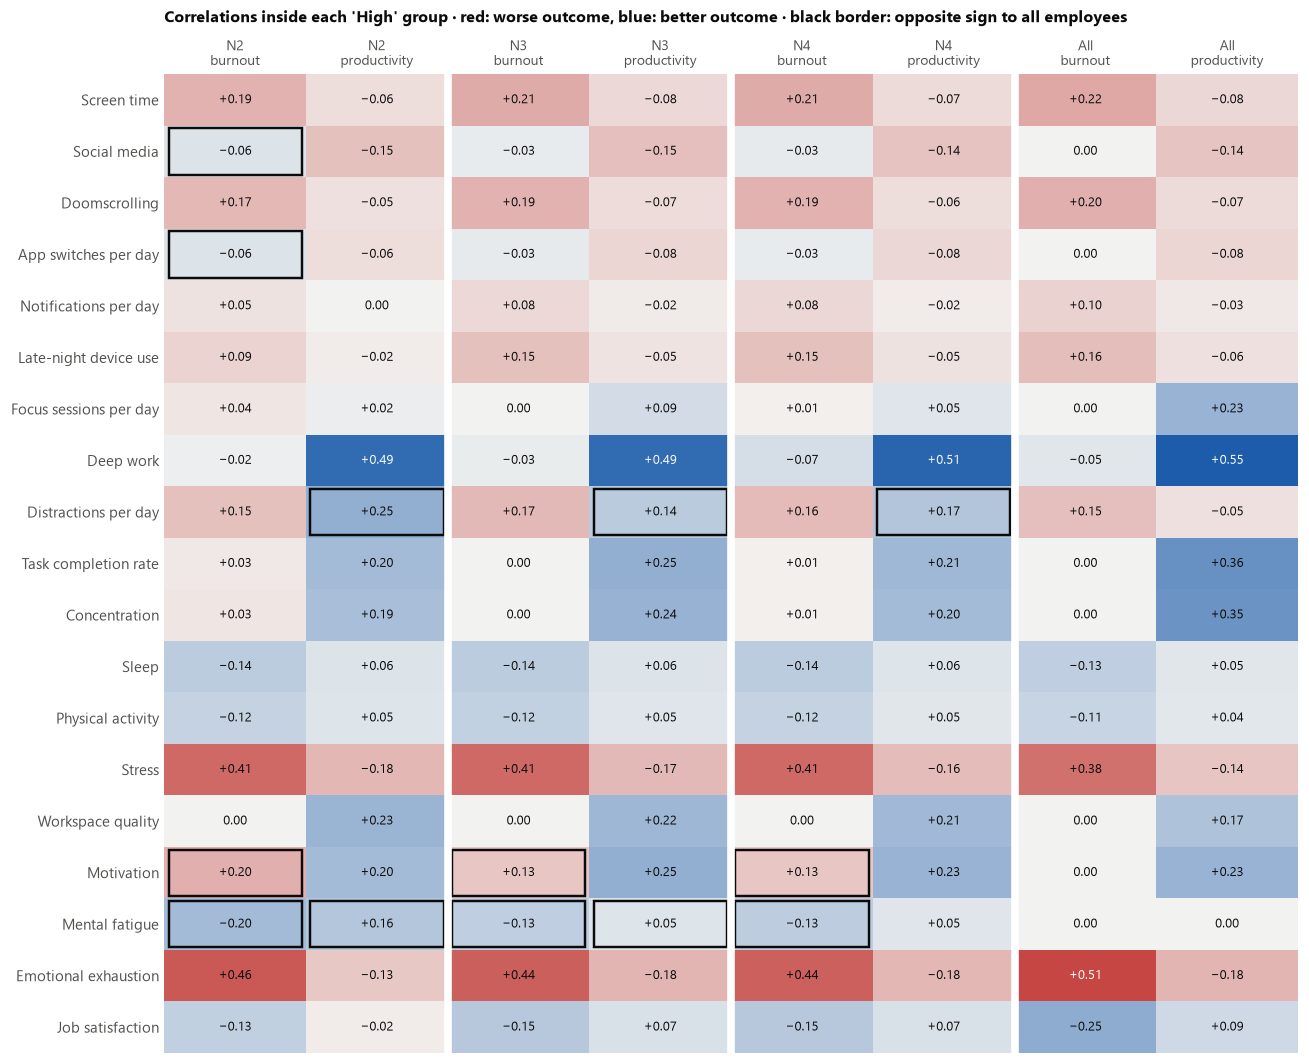

In [36]:
harm_sign = np.array([1 if t == "burnout_risk" else -1 for _, t in wc.columns])
vals = wc.to_numpy()
harm = vals * harm_sign
pop_cols = [i for i, (g, _) in enumerate(wc.columns) if g == "All"]
fig, ax = plt.subplots(figsize=(12, 0.42 * len(wc) + 1.8))
ax.imshow(harm, cmap=P.DIVERGING, vmin=-0.55, vmax=0.55, aspect="auto")
col_labels = [f"{g}\n{'burnout' if t == 'burnout_risk' else 'productivity'}" for g, t in wc.columns]
ax.set_xticks(range(len(col_labels)), col_labels, fontsize=9)
ax.set_yticks(range(len(wc)), [short(c) for c in wc.index], fontsize=9.5)
ax.xaxis.tick_top()
for i in range(vals.shape[0]):
    for j in range(vals.shape[1]):
        ax.text(j, i, P.num(vals[i, j], 2, signed=True), ha="center", va="center", fontsize=8.5,
                color=P.text_on(P.cmap_hex(P.DIVERGING, (harm[i, j] + 0.55) / 1.1)))
        pop_v = vals[i, pop_cols[0] if wc.columns[j][1] == "burnout_risk" else pop_cols[1]]
        is_flip = abs(vals[i, j]) >= 0.05 and (abs(pop_v) < 0.005 or np.sign(vals[i, j]) != np.sign(pop_v))
        if wc.columns[j][0] != "All" and is_flip:
            ax.add_patch(Rectangle((j - 0.47, i - 0.45), 0.94, 0.9, fill=False, ec=P.INK, lw=1.6))
for x in np.arange(1.5, vals.shape[1] - 1, 2):
    ax.axvline(x, color=P.SURFACE, lw=5)
for sp in ax.spines.values():
    sp.set_visible(False)
ax.set_title(f"Correlations inside each '{FOCUS_LEVEL}' group · red: worse outcome, blue: better outcome · black border: opposite sign to all employees",
             fontsize=10.5, pad=34)
fig.tight_layout()
P.save(fig, "08_within_group_corr")
plt.show()

In [37]:
def robust_levers(seg_ids, t, min_r=0.10):
    cols = [(code[s], t) for s in seg_ids]
    sub = wc_all[cols]
    pop = wc_all[("All", t)]
    same_sign = sub.apply(lambda col: np.sign(col) == np.sign(pop)).all(axis=1)
    strong = (sub.abs() >= min_r).all(axis=1) & (pop.abs() >= 0.05)  # a near-zero population r has no reliable sign
    res = sub[same_sign & strong].copy()
    res["All"] = pop
    return res.reindex(res.abs().mean(axis=1).sort_values(ascending=False).index)

def flipped(seg_ids):
    rows = []
    for s in seg_ids:
        for t in OUTCOMES:
            w, p = wc_all[(code[s], t)], wc_all[("All", t)]
            bad = (w.abs() >= 0.05) & ((np.sign(w) != np.sign(p)) | (p.abs() < 0.005))
            for c in w.index[bad]:
                rows.append({"group": code[s], "outcome": lab(t), "factor": short(c), "r in group": w[c], "r all": p[c]})
    return pd.DataFrame(rows)

for t in OUTCOMES:
    print(f"Factors with the same direction in every '{FOCUS_LEVEL}' group — {lab(t)} (|r| ≥ 0.10):")
    display(robust_levers(focus, t).rename(index=short).round(3))
print("Correlations that change sign or only appear inside a group (selection effect, not for decisions):")
flipped(focus).round(3)

Factors with the same direction in every 'High' group — Burnout risk (0-100) (|r| ≥ 0.10):


,N2,N3,N4,All
,burnout_risk,burnout_risk,burnout_risk,
Emotional exhaustion,0.46,0.44,0.44,0.51
Stress,0.41,0.41,0.41,0.38
Screen time,0.19,0.21,0.21,0.22
Doomscrolling,0.17,0.19,0.19,0.20
Job satisfaction,-0.13,-0.15,-0.15,-0.25
Distractions per day,0.15,0.17,0.16,0.15
Sleep,-0.14,-0.14,-0.14,-0.13
Physical activity,-0.12,-0.12,-0.12,-0.11


Factors with the same direction in every 'High' group — Productivity score (0-100) (|r| ≥ 0.10):


,N2,N3,N4,All
,productivity_score,productivity_score,productivity_score,
Deep work,0.49,0.49,0.51,0.56
Task completion rate,0.20,0.25,0.21,0.36
Concentration,0.19,0.24,0.20,0.35
Motivation,0.20,0.25,0.23,0.23
Workspace quality,0.23,0.22,0.21,0.17
Emotional exhaustion,-0.13,-0.18,-0.18,-0.18
Stress,-0.18,-0.17,-0.16,-0.14
Social media,-0.15,-0.15,-0.14,-0.14


Correlations that change sign or only appear inside a group (selection effect, not for decisions):


,group,outcome,factor,r in group,r all
0,N2,Burnout risk (0-100),Social media,-0.06,-0.00
1,N2,Burnout risk (0-100),App switches per day,-0.06,-0.00
2,N2,Burnout risk (0-100),Phone unlocks per day,-0.06,-0.00
3,N2,Burnout risk (0-100),Motivation,0.20,0.00
4,N2,Burnout risk (0-100),Mental fatigue,-0.20,-0.00
5,N2,Productivity score (0-100),Distractions per day,0.25,-0.05
6,N2,Productivity score (0-100),Mental fatigue,0.16,0.00
7,N3,Burnout risk (0-100),Motivation,0.13,0.00
8,N3,Burnout risk (0-100),Mental fatigue,-0.13,-0.00
9,N3,Productivity score (0-100),Distractions per day,0.14,-0.05


### 4.5 The "Low" level: are N5 and N6 alike?

In [38]:
stable = [s for s in order if level[s][0] == "Low"]
for s in stable:
    print(f"{code[s]} · {names[s]}")
st_cmp = pd.DataFrame({code[s]: {
    "burnout mean": outcome_mean.loc[s, "burnout_risk"],
    "productivity mean": outcome_mean.loc[s, "productivity_score"],
    "% low productivity": flag_rate_seg.loc[s, "Low productivity category"] * 100,
    **{f"[score] {PROBLEM_LABELS[c]}": problem_z.loc[s, c] for c in INDEX_COLS}} for s in stable})
st_cmp

N5 · Light device use
N6 · Strong focus + low mental strain


,N5,N6
burnout mean,42.60,38.41
productivity mean,76.19,90.88
% low productivity,6.76,0.39
[score] Digital overload,-1.06,0.00
[score] Poor recovery,-0.00,0.00
[score] Low focus,0.02,-1.04
[score] Mental strain,-0.00,-0.96
[score] Poor environment,-0.00,0.00


**What this shows (part 4)**
- The **"High"** level has 3 groups (about 50% of employees) with **three different main problems**:
  - **N2 – Heavy device use:** the issue is *burnout* (54.6), together with screens, notifications and late-night
    device use (83% use devices late at night, 33% have more than 10 hours of screen time). Productivity is a little
    below average.
  - **N3 – Low focus + low mental strain:** burnout is **below** average (41.2) but *productivity* is lower (63.8),
    and 42% do less than 2 hours of deep work. This is about **how work is organised**, not mental health.
  - **N4 – Mental strain + strong focus:** productivity is **above** average (80.4) but burnout is 55.8 and about half
    report high emotional exhaustion. These are strong performers who may be at risk of leaving.
  → One programme for the whole "High" level would fit one of these groups and miss the other two.
- Inside every group, the main factors **keep their direction**: stress, emotional exhaustion, screen time,
  doomscrolling and distractions go with higher burnout; sleep, physical activity and job satisfaction go with lower
  burnout; deep work, task completion, concentration, motivation and workspace quality go with higher productivity.
  These are good shared KPIs to track.
- Some correlations **change sign** inside a group (for example, *distractions* go with slightly **higher**
  productivity inside N2, N3 and N4). This comes from how the groups were formed; it does **not** mean distractions
  help productivity.
- The **"Low"** level is not uniform either: N6 is strong on focus and mental state (productivity 90.9), while N5
  stands out only for light device use. N6 is the natural source of peer mentors.

## 5. Starting points for solutions
The actions below are **hypotheses** to test (ideally with a comparison group), then measure again with the same
indicators.

In [39]:
playbook = []
for s in order:
    pzs = problem_z.loc[s]
    problems = pzs[pzs >= NAME_THRESHOLD].sort_values(ascending=False)
    strengths = pzs[pzs <= -NAME_THRESHOLD].sort_values()
    actions = [a for c in problems.index for a in INTERVENTIONS[c][:2]] or [MAINTAIN_ACTION]
    playbook.append({"code": code[s], "name": names[s], "risk level": level[s][0],
                     "share %": round(sizes[s] / len(df) * 100, 1),
                     "main problems": "; ".join(f"{PHRASE_PROBLEM[c]} (+{pzs[c]:.2f} SD)" for c in problems.index) or "–",
                     "strengths": "; ".join(f"{PHRASE_STRENGTH[c]} ({pzs[c]:.2f} SD)" for c in strengths.index) or "–",
                     "suggested actions": " | ".join(actions[:4])})
playbook_df = pd.DataFrame(playbook).set_index("code")
display(playbook_df)
cw = pd.DataFrame([{"warning sign": f, "share %": flags[f].mean() * 100, "gap between groups (pp)": flag_spread[f],
                    "company-wide action": COMPANY_WIDE_ACTIONS.get(f, "")} for f in company_wide])
cw

,name,risk level,share %,main problems,strengths,suggested actions
code,,,,,,
N1,Low focus + mental strain,Very high,16.70,low focus (+1.03 SD); mental strain (+0.98 SD),–,Protected deep-work blocks or meeting-free days; fewer context switches | Training on ...
N2,Heavy device use,High,16.60,heavy device use (+1.05 SD),–,Right-to-disconnect policy after hours; turn off non-urgent notifications | Batch noti...
N3,Low focus + low mental strain,High,16.70,low focus (+0.93 SD),low mental strain (-1.08 SD),Protected deep-work blocks or meeting-free days; fewer context switches | Training on ...
N4,Mental strain + strong focus,High,16.80,mental strain (+1.06 SD),strong focus (-0.94 SD),Regular 1:1s with managers; review workload and how clear the goals are | Recognition ...
N5,Light device use,Low,16.50,–,light device use (-1.06 SD),Keep current practices; use as a comparison group and as peer mentors
N6,Strong focus + low mental strain,Low,16.70,–,strong focus (-1.04 SD); low mental strain (-0.96 SD),Keep current practices; use as a comparison group and as peer mentors


,warning sign,share %,gap between groups (pp),company-wide action
0,Sleep under 6 h,34.95,0.09,Company-wide sleep health programme; no work messages after 9 pm
1,High stress (8+),29.99,0.18,Employee assistance programme (EAP) and stress-management training at all levels


**Suggested order of work**
1. **Company-wide (first):** sleep and stress-management programme; do-not-disturb outside working hours.
2. **N1 (very high risk):** protected deep-work time plus regular 1:1s with managers; measure productivity and
   burnout again after one quarter.
3. **N4 (retention):** review workload, recognition, development plans and counselling access; track attrition.
4. **N2:** right-to-disconnect policy and batched notifications; track screen time and late-night device use.
5. **N3:** time-management training and meeting-free days; track deep-work hours and task completion.
6. **N5, N6:** keep current practices; use as comparison groups and peer mentors.

## 6. Export results for the reports
The files below are the inputs for `src/build_report_html.py` and `src/build_report_excel.py`.

In [40]:
REPORTS.mkdir(exist_ok=True)
save_csv = lambda d, name, **kw: d.to_csv(REPORTS / name, encoding="utf-8", **kw)  # noqa: E731
save_csv(schema, "01_schema.csv")
save_csv(desc, "01_numeric_describe.csv")
save_csv(cat_summary, "01_categorical_summary.csv", index=False)
save_csv(corr.round(4), "01_correlation_matrix.csv")
save_csv(r_out.round(4), "02_driver_correlation.csv")
save_csv(flag_tbl, "02_red_flags.csv")
save_csv(by_dim, "02_outcomes_by_profile.csv", index=False)
save_csv(k_tbl.round(4), "03_k_selection.csv")
save_csv(summary.round(4), "03_segment_summary.csv")
save_csv(pz.rename(index=code, columns=PROBLEM_LABELS).round(4), "03_segment_problem_scores.csv")
save_csv(fr.round(3), "03_segment_red_flags.csv")
raw_tbl = raw_mean.loc[order].rename(index=code).T
raw_tbl["All"] = pd.concat([pop_mean, num_imp[OUTCOMES].mean()])
raw_tbl["SD"] = pd.concat([pop_std, num_imp[OUTCOMES].std()])
save_csv(raw_tbl.round(4), "04_segment_raw_means.csv")
save_csv(raw_z.loc[order].rename(index=code).T.round(4), "04_segment_raw_zscores.csv")
groups = list(dict.fromkeys(wc_all.columns.get_level_values(0)))
wc_long = pd.concat({g: wc_all[g] for g in groups}, names=["group", "driver"]).reset_index()
save_csv(wc_long.round(4), "04_within_group_correlation.csv", index=False)
save_csv(playbook_df, "05_playbook.csv")

df[["user_id", "segment_id"]].to_parquet(PROCESSED / "segment_assignment.parquet", index=False)
df.drop(columns="segment_id").to_parquet(PROCESSED / "employees.parquet", index=False)

meta = {
    "n_rows": int(len(df)), "k": K, "weights": weights.round(4).to_dict(),
    "k_table": k_tbl.reset_index().round(4).to_dict(orient="records"),
    "silhouette": float(validation.iloc[3]), "ari_sample_vs_full": float(validation.iloc[0]),
    "ari_gmm": float(validation.iloc[1]), "ari_ward": float(validation.iloc[2]),
    "pca_explained": [float(v) for v in pca.explained_variance_ratio_], "eta2": eta,
    "index_cols": INDEX_COLS, "index_labels": INDEX_LABELS, "problem_labels": PROBLEM_LABELS, "problem_sign": PROBLEM_SIGN,
    "index_members": {k: list(v) for k, v in INDEX_DEF.items()},
    "order": [int(s) for s in order],
    "segments": [{
        "segment_id": int(s), "code": code[s], "name": names[s], "label": f"{code[s]} · {names[s]}",
        "level": level[s][0], "status": level[s][1], "n": int(sizes[s]), "share": float(sizes[s] / len(df)),
        "burnout": float(outcome_mean.loc[s, "burnout_risk"]), "productivity": float(outcome_mean.loc[s, "productivity_score"]),
        "risk_score": round(float(risk_score[s]), 4),
        "problems": [{"index": c, "text": PHRASE_PROBLEM[c], "z": round(float(problem_z.loc[s, c]), 3)}
                     for c in problem_z.loc[s][problem_z.loc[s] >= NAME_THRESHOLD].sort_values(ascending=False).index],
        "strengths": [{"index": c, "text": PHRASE_STRENGTH[c], "z": round(float(problem_z.loc[s, c]), 3)}
                      for c in problem_z.loc[s][problem_z.loc[s] <= -NAME_THRESHOLD].sort_values().index],
        "actions": p["suggested actions"].split(" | "),
    } for s, p in zip(order, playbook)],
    "risk_levels": [{"min": (None if np.isinf(t) else t), "label": lv, "status": st} for t, lv, st in RISK_LEVELS],
    "company_wide": [{"flag": f, "rate": round(float(flags[f].mean() * 100), 2), "spread_pp": round(float(flag_spread[f]), 2),
                      "action": COMPANY_WIDE_ACTIONS.get(f, "")} for f in company_wide],
    "focus_level": FOCUS_LEVEL,
}
(REPORTS / "segment_meta.json").write_text(json.dumps(meta, indent=2, ensure_ascii=False), encoding="utf-8")
for p in sorted(REPORTS.iterdir()):
    print(f"{p.relative_to(ROOT)}  ({p.stat().st_size / 1024:,.0f} KB)")

reports\01_categorical_summary.csv  (1 KB)
reports\01_correlation_matrix.csv  (6 KB)
reports\01_numeric_describe.csv  (5 KB)
reports\01_schema.csv  (2 KB)
reports\02_driver_correlation.csv  (2 KB)
reports\02_outcomes_by_profile.csv  (1 KB)
reports\02_red_flags.csv  (0 KB)
reports\03_k_selection.csv  (1 KB)
reports\03_segment_problem_scores.csv  (0 KB)
reports\03_segment_red_flags.csv  (1 KB)
reports\03_segment_summary.csv  (1 KB)
reports\04_segment_raw_means.csv  (2 KB)
reports\04_segment_raw_zscores.csv  (2 KB)
reports\04_within_group_correlation.csv  (6 KB)
reports\05_playbook.csv  (1 KB)
reports\segment_meta.json  (10 KB)


## 7. Conclusions

1. **Burnout and productivity are separate problems.** Burnout goes with emotional exhaustion, stress and digital
   habits; productivity goes with deep work and focus. They need separate KPIs and separate types of support.
2. **The differences are not about job title or work mode.** They are in individual behaviour, so groups are based
   on behaviour.
3. **Six employee groups** explain 37% of the variation in productivity. N1 (low focus + mental strain) has the
   highest risk.
4. **The same risk level does not mean the same solution.** The three "High" groups have three different main
   problems. N4 combines high productivity with high burnout, so it can be missed if only productivity is tracked.
5. **Short sleep and high stress** are at the same level in every group, so they need company-wide measures.

*Limitations:* the data is synthetic; correlation is not causation; the groups are a practical way to divide the
risk space, not natural "types" of people. Interactive report: `visualize/report.html`; tables and charts in Excel:
`visualize/report.xlsx`.